# Esophageal Cancer Research - Association Rule Mining
* By Sangwon Baek
* Samsung Medical Center
* August 3rd, 2023

### Import necessary packages and read data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.frequent_patterns import fpgrowth
from matplotlib.colors import LinearSegmentedColormap

from statsmodels.graphics.mosaicplot import mosaic
import itertools

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.options.mode.chained_assignment = None

In [2]:
df = pd.read_csv("../Data/Preprocessed/ECA_Dataset.csv").drop(columns="Unnamed: 0")

In [3]:
def N_categorize(x):
    if x == 0:
        return '0'
    elif 1 <= x <= 2:
        return '1'
    elif 3 <= x <= 6:
        return '2'
    else: # x > 7
        return '3'

# Listing the columns that start with "pos_" and "total_"
pos_columns = [col for col in df.columns if col.startswith("pos_")]
total_columns = [col for col in df.columns if col.startswith("total_")]
    
# Extract T, N, and M categories using regular expressions and then remove the prefixes
df['T_category'] = df['pTNM7_1'].str.extract('(TX|T0|Tis|T1a|T1b|T2|T3|T4a|T4b)').replace('T', '', regex=True)
df['N_category'] = df.total_pos_LN.apply(N_categorize)
df['M_category'] = df['pTNM7_1'].str.extract('(M0|M1)').replace('M', '', regex=True)

#Create the df with the whole dataset
Whole_df = df.copy() 

#Create the subgroup dfs for the subgroup analysis
Whole_upper_df = df.loc[df.Primary_Site=='upper']
Whole_mid_df = df.loc[df.Primary_Site=='mid']
Whole_lower_df = df.loc[df.Primary_Site=='lower']

# Filtering out 'is' category and creating the two groups
T1_df = df[df['T_category'].isin(['1a', '1b'])]
T24_df = df[df['T_category'].isin(['2', '3', '4a', '4b'])]
T2_df = df[df['T_category'].isin(['2'])]
T3_df = df[df['T_category'].isin(['3'])]
T4_df = df[df['T_category'].isin(['4a', '4b'])]

#Create the subgroup dfs for the subgroup analysis
T1_upper_df = T1_df.loc[T1_df.Primary_Site=='upper']
T1_mid_df = T1_df.loc[T1_df.Primary_Site=='mid']
T1_lower_df = T1_df.loc[T1_df.Primary_Site=='lower']

T24_upper_df = T24_df.loc[T24_df.Primary_Site=='upper']
T24_mid_df = T24_df.loc[T24_df.Primary_Site=='mid']
T24_lower_df = T24_df.loc[T24_df.Primary_Site=='lower']

T2_upper_df = T2_df.loc[T2_df.Primary_Site=='upper']
T2_mid_df = T2_df.loc[T2_df.Primary_Site=='mid']
T2_lower_df = T2_df.loc[T2_df.Primary_Site=='lower']

T3_upper_df = T3_df.loc[T3_df.Primary_Site=='upper']
T3_mid_df = T3_df.loc[T3_df.Primary_Site=='mid']
T3_lower_df = T3_df.loc[T3_df.Primary_Site=='lower']

T4_upper_df = T4_df.loc[T4_df.Primary_Site=='upper']
T4_mid_df = T4_df.loc[T4_df.Primary_Site=='mid']
T4_lower_df = T4_df.loc[T4_df.Primary_Site=='lower']

In [4]:
#Describe the datsets 
dataset_descriptors = ["Whole", "Whole_upper", "Whole_mid", "Whole_lower", 
                       "T1", "T1_upper", "T1_mid", "T1_lower", 
                       "T24", "T24_upper", "T24_mid", "T24_lower",
                       "T2", "T2_upper", "T2_mid", "T2_lower",
                       "T3", "T3_upper", "T3_mid", "T3_lower",
                       "T4", "T4_upper", "T4_mid", "T4_lower"]

#Define the numbers and N_categories I want to test 
numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 44]
N_categories = ['0','1','2','3']

# Use the function
dfs = [
    ("Whole", Whole_df), 
    ("Whole Upper", Whole_upper_df), 
    ("Whole Mid", Whole_mid_df), 
    ("Whole Lower", Whole_lower_df), 
    ("T1", T1_df), 
    ("T1 upper", T1_upper_df), 
    ("T1 mid", T1_mid_df), 
    ("T1 lower", T1_lower_df), 
    ("T2", T2_df), 
    ("T2 upper", T2_upper_df), 
    ("T2 mid", T2_mid_df), 
    ("T2 lower", T2_lower_df), 
    ("T3", T3_df), 
    ("T3 upper", T3_upper_df), 
    ("T3 mid", T3_mid_df), 
    ("T3 lower", T3_lower_df), 
    ("T4", T4_df), 
    ("T4 upper", T4_upper_df), 
    ("T4 mid", T4_mid_df), 
    ("T4 lower", T4_lower_df), 
    ("T24", T24_df), 
    ("T24 upper", T24_upper_df),
    ("T24 mid", T24_mid_df),
    ("T24 lower", T24_lower_df)
]

In [5]:
def patient_counts(*dataframes):
    # Create a dictionary with conditions as keys to store results
    counts_dict = { "Data Type": [] }
    for i in range(1, 20):
        counts_dict[f"upto {i}"] = []

    # Define the conditions
    conditions = [f"upto {i}" for i in range(1, 20)]

    # Loop through each dataframe and calculate counts
    for df_name, df in dataframes:
        counts_dict["Data Type"].append(df_name)
        for cond in conditions:
            limit = int(cond.split(" ")[1])  # Extracting the number from the condition string
            value = len(df.loc[(df.total_pos_LN >= 1) & (df.total_pos_LN <= limit)])
            counts_dict[cond].append(value)

    # Convert the dictionary to a DataFrame and return
    return pd.DataFrame(counts_dict)

def patient_counts_by_category(*dataframes):
    # Create a dictionary with conditions as keys to store results
    counts_dict = {"Data Type": []}

    # Extract all unique N_category values from the dataframes
    all_categories = set()
    for _, df in dataframes:
        all_categories.update(df['N_category'].unique())
    all_categories = sorted(list(all_categories))

    # Initialize counts_dict with all_categories as keys
    for cat in all_categories:
        counts_dict[cat] = []

    # Loop through each dataframe and calculate counts
    for df_name, df in dataframes:
        counts_dict["Data Type"].append(df_name)
        for cat in all_categories:
            value = len(df[df['N_category'] == cat])
            counts_dict[cat].append(value)

    # Convert the dictionary to a DataFrame and return
    return pd.DataFrame(counts_dict)

In [6]:
result_df = patient_counts(*dfs)
result_df.to_csv("../Results/data_lengths.csv")
result_df

,Data Type,upto 1,upto 2,upto 3,upto 4,upto 5,upto 6,upto 7,upto 8,upto 9,upto 10,upto 11,upto 12,upto 13,upto 14,upto 15,upto 16,upto 17,upto 18,upto 19
0,Whole,416,655,816,923,985,1023,1058,1082,1096,1112,1127,1136,1142,1146,1156,1158,1162,1165,1168
1,Whole Upper,47,70,89,101,108,113,116,116,120,124,124,125,125,125,126,126,128,129,129
2,Whole Mid,210,325,400,453,481,499,512,524,526,533,539,545,548,551,556,557,557,557,557
3,Whole Lower,159,260,327,369,395,410,429,441,449,454,463,465,468,469,473,474,476,478,481
4,T1,213,295,340,364,376,379,381,385,386,388,390,391,391,391,391,391,391,391,391
5,T1 upper,27,38,43,45,46,46,46,46,46,47,47,47,47,47,47,47,47,47,47
6,T1 mid,110,146,169,181,187,188,189,191,191,191,192,193,193,193,193,193,193,193,193
7,T1 lower,76,111,128,138,143,145,146,148,149,150,151,151,151,151,151,151,151,151,151
8,T2,72,112,141,158,166,171,176,180,181,182,186,188,190,190,191,192,192,193,193
9,T2 upper,6,9,13,17,18,18,19,19,20,21,21,21,21,21,22,22,22,23,23


In [7]:
result2_df = patient_counts_by_category(*dfs)
result2_df.to_csv("../Results/N_category_lengths.csv")
result2_df

,Data Type,0,1,2,3
0,Whole,1482,655,368,158
1,Whole Upper,143,70,43,16
2,Whole Mid,776,325,174,67
3,Whole Lower,563,260,150,75
4,T1,1076,295,84,12
5,T1 upper,97,38,8,1
6,T1 mid,563,146,42,5
7,T1 lower,416,111,34,6
8,T2,156,112,59,24
9,T2 upper,17,9,9,5


### Association Rule Mining PS

In [8]:
def transaction_encoder(transactions):
    te = TransactionEncoder()
    oht = te.fit_transform(transactions)
    df_oht = pd.DataFrame(oht, columns=te.columns_)
    return df_oht

# Function to save dataframes to multiple sheets
def save_to_excel(filename, dataframes):
    with pd.ExcelWriter(filename) as writer:
        for name, df in dataframes:
            df.to_excel(writer, sheet_name=name)

In [9]:
def convert_to_lymph_transactions_PS(df):
    transactions = []

    # Getting all columns related to positive lymph node stations
    pos_columns = [col for col in df.columns if col.startswith('pos_')]

    # Excluding the specified columns from the lymph node stations
    excluded_columns = ["pos_neckLN", "pos_mediaLN", "pos_abdoLN", "total_pos_LN"]
    specific_pos_columns = [col for col in pos_columns if col not in excluded_columns]

    for index, row in df.iterrows():        
        # Extracting the specific lymph node stations with positive counts (removing "pos_" prefix)
        nodes = [col[4:] for col in specific_pos_columns if pd.to_numeric(row[col], errors='coerce') > 0]
        
        # Including the primary site in the transaction
        transaction = [str(row['Primary_Site'])] + [str(item) for item in nodes if item is not None]
        
        if len(transaction) >= 2:  # Only consider transactions with at least a primary site and one lymph node
            transactions.append(transaction)
        
    return transactions

def association_rule_mining_PS(df, count, category, min_support, min_confidence, filterCount):
    if count == None:
        df_temp = df[df['N_category'] == category]
    if category == None:
        df_temp = df[df['total_pos_LN'] <= count]
    
    # Convert the dataset into lymph node transactions format
    lymph_transactions = convert_to_lymph_transactions_PS(df_temp)

    # Convert to transaction encoder df
    transaction_df = transaction_encoder(lymph_transactions)
    
    # Run fpgrowth
    frequent_itemsets = fpgrowth(transaction_df, min_support=min_support, use_colnames=True).sort_values(by='support', ascending=False)

    # Identify association rules
    try:
        rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence).sort_values(by="support", ascending=False)
        
        # Check if any rules were found
        if rules.empty:
            if count==None:
                print(f"No frequent itemsets found for N_category: {category}")
            if category==None:
                print(f"No frequent itemsets found for count: {count}")
            return pd.DataFrame()

        # Ensure primary sites ('lower', 'mid', 'upper') are only in the antecedents
        # and specific lymphnode locations are only in the consequents
        primary_sites = ['lower', 'mid', 'upper']
        rules = rules[rules['antecedents'].apply(lambda x: list(x)[0] in primary_sites)]
        rules = rules[rules['consequents'].apply(lambda x: list(x)[0] not in primary_sites)]
        # (rules['antecedents'].apply(lambda x: len(x) == 1)) & 
        # Filter rules with only one item in the antecedent and consequent
        if filterCount == 1:
            rules = rules[(rules['antecedents'].apply(lambda x: len(x) == 1)) & (rules['consequents'].apply(lambda x: len(x) == 1))]
        elif filterCount == 2:
            rules = rules[(rules['antecedents'].apply(lambda x: len(x) == 1)) & (~rules['consequents'].apply(lambda x: len(x) == 1))]

        # Convert antecedents and consequents from frozenset to string
        rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
        rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

        # Calculate the actual count of each rule
        rules['count'] = rules['support'] * len(lymph_transactions)

        # # Filter out rows where 'count' is equal to 1
        # rules = rules[rules['count'] != 1]
        
        # Include selected columns
        IncludeColumns = ['antecedents', 'consequents', 'count', 'support', 'confidence', 'lift'] 
        associationRule = rules[IncludeColumns]
        
        return associationRule

    except Exception as e:
        if count==None:
            print(f"Error for N_category {category}: {e}")
        if category==None:
            print(f"Error for count {count}: {e}")
        return pd.DataFrame()

def combine_association_rules_PS(descriptor):
    numbers = ['N1', 'N2', 'N3', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'all']
    dfs = []

    for num in numbers:
        df_name = f"associationRule_PS_{num}_{descriptor}"
        
        # Check if dataframe with the name exists
        if df_name in globals():
            df = globals()[df_name]
            df = df.reset_index(drop=True)  # Reset the index
            df.columns = pd.MultiIndex.from_product([[num], df.columns])
            dfs.append(df)

    combined_df = pd.concat(dfs, axis=1)
    return combined_df

def combine_association_rules_PS_2(descriptor):
    numbers = ['N1', 'N2', 'N3', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'all']
    dfs = []

    for num in numbers:
        df_name = f"associationRule_PS_2_{num}_{descriptor}"
        
        # Check if dataframe with the name exists
        if df_name in globals():
            df = globals()[df_name]
            df = df.reset_index(drop=True)  # Reset the index
            df.columns = pd.MultiIndex.from_product([[num], df.columns])
            dfs.append(df)

    combined_df = pd.concat(dfs, axis=1)
    return combined_df

def combine_AR_PS_N_category(descriptor):
    numbers = ['N1', 'N2', 'N3']
    dfs = []

    for num in numbers:
        df_name = f"associationRule_PS_{num}_{descriptor}"
        
        # Check if dataframe with the name exists
        if df_name in globals():
            df = globals()[df_name]
            df = df.reset_index(drop=True)  # Reset the index
            df.columns = pd.MultiIndex.from_product([[num], df.columns])
            dfs.append(df)

    combined_df = pd.concat(dfs, axis=1)
    return combined_df

def combine_AR_PS_N_category_2(descriptor):
    numbers = ['N1', 'N2', 'N3']
    dfs = []

    for num in numbers:
        df_name = f"associationRule_PS_2_{num}_{descriptor}"
        
        # Check if dataframe with the name exists
        if df_name in globals():
            df = globals()[df_name]
            df = df.reset_index(drop=True)  # Reset the index
            df.columns = pd.MultiIndex.from_product([[num], df.columns])
            dfs.append(df)

    combined_df = pd.concat(dfs, axis=1)
    return combined_df

In [10]:
for descriptor in dataset_descriptors:
    for num in numbers:
        label = 'all' if num == 44 else str(num)
        globals()[f"associationRule_PS_{label}_{descriptor}"] = association_rule_mining_PS(globals()[f"{descriptor}_df"], num, None, 0.01, 0.01 if num != 44 else 0.03, 1)
        globals()[f"associationRule_PS_2_{label}_{descriptor}"] = association_rule_mining_PS(globals()[f"{descriptor}_df"], num, None, 0.01, 0.01 if num != 44 else 0.03, 2)

Error for count 1: The input DataFrame `df` containing the frequent itemsets is empty.
Error for count 1: The input DataFrame `df` containing the frequent itemsets is empty.


In [11]:
#Get association rule based on N_Category
for descriptor in dataset_descriptors:
    for category in N_categories:
        label = f'N{category}'
        globals()[f"associationRule_PS_{label}_{descriptor}"] = association_rule_mining_PS(globals()[f"{descriptor}_df"], None, category, 0.01, 0.01, 1)
        globals()[f"associationRule_PS_2_{label}_{descriptor}"] = association_rule_mining_PS(globals()[f"{descriptor}_df"], None, category, 0.01, 0.01, 2)

Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemset

In [12]:
# 1. Combine datasets using loops and dictionaries
sections_PS = ['Whole', 'T1', 'T24', 'T2', 'T3', 'T4']
subsections_PS = ['', '_upper', '_mid', '_lower']

combined_data_PS = {}
combined_data_PS_N = {}

for section in sections_PS:
    for sub in subsections_PS:
        key = f"combined_PS_{section}{sub}"
        combined_data_PS[key] = combine_association_rules_PS(f"{section}{sub}")
        combined_data_PS_N[key] = combine_AR_PS_N_category(f"{section}{sub}")

# 2. Create the association_rules_PS_dfs list from the dictionary
association_rules_PS_dfs = [(key.replace("combined_PS_", ""), combined_data_PS[key]) for key in combined_data_PS]
association_rules_PS_N_dfs = [(key.replace("combined_PS_", ""), combined_data_PS_N[key]) for key in combined_data_PS_N]

# Save the dataframes to separate sheets in a single Excel file
save_to_excel('../Results/association_rules_PS.xlsx', association_rules_PS_dfs)
save_to_excel('../Results/association_rules_PS_Ncategory.xlsx', association_rules_PS_N_dfs)

In [13]:
combined_data_PS_2 = {}
combined_data_PS_2_N = {}

for section in sections_PS:
    for sub in subsections_PS:
        key = f"combined_PS_{section}{sub}"
        combined_data_PS_2[key] = combine_association_rules_PS_2(f"{section}{sub}")
        combined_data_PS_2_N[key] = combine_AR_PS_N_category_2(f"{section}{sub}")

# 2. Create the association_rules_PS_dfs list from the dictionary
association_rules_PS_2_dfs = [(key.replace("combined_PS_", ""), combined_data_PS_2[key]) for key in combined_data_PS_2]
association_rules_PS_2_N_dfs = [(key.replace("combined_PS_", ""), combined_data_PS_2_N[key]) for key in combined_data_PS_2_N]

# Save the dataframes to separate sheets in a single Excel file
save_to_excel('../Results/association_rules_PS_2.xlsx', association_rules_PS_2_dfs)
save_to_excel('../Results/association_rules_PS_Ncategory_2.xlsx', association_rules_PS_2_N_dfs)

### Association Rule Mining TN

In [14]:
def convert_to_lymph_transactions(df):
    transactions = []

    # Getting all columns related to positive lymph node stations
    pos_columns = [col for col in df.columns if col.startswith('pos_')]

    # Excluding the specified columns from the lymph node stations
    excluded_columns = ["pos_neckLN", "pos_mediaLN", "pos_abdoLN", "total_pos_LN"]
    specific_pos_columns = [col for col in pos_columns if col not in excluded_columns]

    for index, row in df.iterrows():        
        # Extracting the specific lymph node stations with positive counts (removing "pos_" prefix)
        nodes = [col[4:] for col in specific_pos_columns if pd.to_numeric(row[col], errors='coerce') > 0]
        
        # Ensuring all items are strings
        transaction = [str(item) for item in nodes if item is not None]
        if len(transaction) >= 1:  # Only consider transactions with at least two lymph nodes
            transactions.append(transaction)
        
    return transactions

def association_rule_mining_TN(df, count, category, min_support, min_confidence, filterCount):
    if count == None:
        df_temp = df[df['N_category'] == category]
    if category == None:
        df_temp = df[df['total_pos_LN'] <= count]

    # Convert the dataset into lymph node transactions format
    lymph_transactions = convert_to_lymph_transactions(df_temp)

    # Convert to transaction encoder df
    transaction_df = transaction_encoder(lymph_transactions)
    
    # Run fpgrowth
    frequent_itemsets = fpgrowth(transaction_df, min_support=min_support, use_colnames=True).sort_values(by='support', ascending=False)

    # Identify association rules
    try:
        rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence).sort_values(by="support", ascending=False).sort_values(by="lift", ascending=False)
        
        # Check if any rules were found
        if rules.empty:
            if count==None:
                print(f"No frequent itemsets found for N_category: {category}")
            if category==None:
                print(f"No frequent itemsets found for count: {count}")
            return pd.DataFrame()
        
        # Filter rules with only one item in the antecedent and consequent
        if filterCount == 1:
            rules = rules[(rules['antecedents'].apply(lambda x: len(x) == 1)) & (rules['consequents'].apply(lambda x: len(x) == 1))]
        elif filterCount == 2:
            rules = rules[(rules['antecedents'].apply(lambda x: len(x) == 2)) | (rules['consequents'].apply(lambda x: len(x) == 2))]
        elif filterCount == 3:
            rules = rules[(rules['antecedents'].apply(lambda x: len(x) == 3)) | (rules['consequents'].apply(lambda x: len(x) == 3))]
        
        # Convert antecedents and consequents from frozenset to string
        rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
        rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

        # Calculate the actual count of each rule
        rules['count'] = rules['support'] * len(lymph_transactions)

        # Filter out rows where 'count' is equal to 1
        # rules = rules[rules['count'] != 1]
        
        # Include selected columns
        IncludeColumns = ['antecedents', 'consequents', 'count', 'support', 'confidence', 'lift'] 
        associationRule = rules[IncludeColumns]
        
        return associationRule

    except Exception as e:
        if count==None:
            print(f"Error for N_category {category}: {e}")
        if category==None:
            print(f"Error for count {count}: {e}")
        return pd.DataFrame()

def combine_association_rules(descriptor):
    numbers = ['N1', 'N2', 'N3', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'all']
    dfs = []

    for num in numbers:
        df_name = f"associationRule_{num}_{descriptor}"
        
        # Check if dataframe with the name exists
        if df_name in globals():
            df = globals()[df_name]
            df = df.reset_index(drop=True)  # Reset the index
            df.columns = pd.MultiIndex.from_product([[num], df.columns])
            dfs.append(df)

    combined_df = pd.concat(dfs, axis=1)
    return combined_df

def combine_association_rules_2(descriptor):
    numbers = ['N1', 'N2', 'N3', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'all']
    dfs = []

    for num in numbers:
        df_name = f"associationRule_2_{num}_{descriptor}"
        
        # Check if dataframe with the name exists
        if df_name in globals():
            df = globals()[df_name]
            df = df.reset_index(drop=True)  # Reset the index
            df.columns = pd.MultiIndex.from_product([[num], df.columns])
            dfs.append(df)

    combined_df = pd.concat(dfs, axis=1)
    return combined_df

def combine_AR_TN_N_Category(descriptor):
    numbers = ['N1', 'N2', 'N3']
    dfs = []

    for num in numbers:
        df_name = f"associationRule_{num}_{descriptor}"
        
        # Check if dataframe with the name exists
        if df_name in globals():
            df = globals()[df_name]
            df = df.reset_index(drop=True)  # Reset the index
            df.columns = pd.MultiIndex.from_product([[num], df.columns])
            dfs.append(df)

    combined_df = pd.concat(dfs, axis=1)
    return combined_df

def combine_AR_TN_N_Category_2(descriptor):
    numbers = ['N1', 'N2', 'N3']
    dfs = []

    for num in numbers:
        df_name = f"associationRule_2_{num}_{descriptor}"
        
        # Check if dataframe with the name exists
        if df_name in globals():
            df = globals()[df_name]
            df = df.reset_index(drop=True)  # Reset the index
            df.columns = pd.MultiIndex.from_product([[num], df.columns])
            dfs.append(df)

    combined_df = pd.concat(dfs, axis=1)
    return combined_df

In [15]:
#Get association rule based on Counts
for descriptor in dataset_descriptors:
    for num in numbers:
        label = 'all' if num == 44 else str(num)
        globals()[f"associationRule_{label}_{descriptor}"] = association_rule_mining_TN(globals()[f"{descriptor}_df"], num, None, 0.01, 0.01 if num != 44 else 0.05, 1)
        globals()[f"associationRule_2_{label}_{descriptor}"] = association_rule_mining_TN(globals()[f"{descriptor}_df"], num, None, 0.01, 0.01 if num != 44 else 0.05, 2)

No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1
No frequent itemsets found for count: 1


In [16]:
#Get association rule based on N_Category
for descriptor in dataset_descriptors:
    for category in N_categories:
        label = f'N{category}'
        globals()[f"associationRule_{label}_{descriptor}"] = association_rule_mining_TN(globals()[f"{descriptor}_df"], None, category, 0.01, 0.01, 1)
        globals()[f"associationRule_2_{label}_{descriptor}"] = association_rule_mining_TN(globals()[f"{descriptor}_df"], None, category, 0.01, 0.01, 2)

Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemsets is empty.
Error for N_category 0: The input DataFrame `df` containing the frequent itemset

In [17]:
# 1. Combine datasets using loops and dictionaries
sections = ['Whole', 'T1', 'T24', 'T2', 'T3', 'T4']
subsections = ['', '_upper', '_mid', '_lower']

combined_data = {}
combined_data_N = {}
for section in sections:
    for sub in subsections:
        key = f"combined_{section}{sub}"
        combined_data[key] = combine_association_rules(f"{section}{sub}")
        combined_data_N[key] = combine_AR_TN_N_Category(f"{section}{sub}")

# 2. Create the association_rules_dfs list from the dictionary
association_rules_TN_dfs = [(key.replace("combined_", ""), combined_data[key]) for key in combined_data]
association_rules_TN_N_dfs = [(key.replace("combined_", ""), combined_data_N[key]) for key in combined_data_N]

# 4. Save the dataframes to separate sheets in a single Excel file
save_to_excel('../Results/association_rules_TN.xlsx', association_rules_TN_dfs)
save_to_excel('../Results/association_rules_TN_Ncategory.xlsx', association_rules_TN_N_dfs)

In [18]:
combined_data_2 = {}
combined_data_2_N = {}
for section in sections:
    for sub in subsections:
        key = f"combined_{section}{sub}"
        combined_data_2[key] = combine_association_rules_2(f"{section}{sub}")
        combined_data_2_N[key] = combine_AR_TN_N_Category_2(f"{section}{sub}")

# 2. Create the association_rules_dfs list from the dictionary
association_rules_TN_2_dfs = [(key.replace("combined_", ""), combined_data_2[key]) for key in combined_data_2]
association_rules_TN_2_N_dfs = [(key.replace("combined_", ""), combined_data_2_N[key]) for key in combined_data_2_N]

# 4. Save the dataframes to separate sheets in a single Excel file
save_to_excel('../Results/association_rules_TN_2.xlsx', association_rules_TN_2_dfs)
save_to_excel('../Results/association_rules_TN_Ncategory_2.xlsx', association_rules_TN_2_N_dfs)

### Visualization of Association Rules

In [19]:
def plot_combined_heatmap_support(df1, df2, df3, name):
    """
    Generate a combined heatmap for N1, N2, and N3 using the provided dataframes.
    """
    
    # Group the dataframes with their respective N categories
    dataframes = {
        'N1': df1,
        'N2': df2,
        'N3': df3
    }
    
    # Custom color map
    color_list = ['#B6DA4D', '#8C362A']
    cmap = LinearSegmentedColormap.from_list("custom_cmap", color_list, N=100)
    
    # Create a figure to hold the subplots
    plt.figure(figsize=(15, 15))
    
    for i, (n_category, df) in enumerate(dataframes.items(), 1):
        # Count the occurrences of each LN location
        ln_location_order = df.sort_values(by='count', ascending=False)['consequents'].unique().tolist()

        # Pivot the data for heatmap visualization
        heatmap_data = df.pivot('antecedents', 'consequents', 'support')
        heatmap_data = heatmap_data[ln_location_order] 
        
        # Create a subplot
        plt.subplot(3, 1, i)
        sns.heatmap(heatmap_data, cmap=cmap, annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': 'Support Value'})
        plt.title(f'Lymph Node Metastasis Heatmap for {name}: {n_category}')
        plt.xlabel('LN Locations (consequents)')
        plt.ylabel('Primary Lesion Sites (antecedents)')
        plt.tight_layout()
    
    plt.show()
    
def plot_combined_heatmap_confidence(df1, df2, df3, name):
    """
    Generate a combined heatmap for N1, N2, and N3 using the provided dataframes.
    """
    
    # Group the dataframes with their respective N categories
    dataframes = {
        'N1': df1,
        'N2': df2,
        'N3': df3
    }
    
    # Custom color map
    color_list = ['#B6DA4D', '#8C362A']
    cmap = LinearSegmentedColormap.from_list("custom_cmap", color_list, N=100)
    
    # Create a figure to hold the subplots
    plt.figure(figsize=(15, 15))
    
    for i, (n_category, df) in enumerate(dataframes.items(), 1):
        # Count the occurrences of each LN location
        ln_location_order = df.sort_values(by='count', ascending=False)['consequents'].unique().tolist()

        # Pivot the data for heatmap visualization
        heatmap_data = df.pivot('antecedents', 'consequents', 'confidence')
        heatmap_data = heatmap_data[ln_location_order] 
        
        # Create a subplot
        plt.subplot(3, 1, i)
        sns.heatmap(heatmap_data, cmap=cmap, annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': 'Confidence Value'})
        plt.title(f'Lymph Node Metastasis Heatmap for {name}: {n_category}')
        plt.xlabel('LN Locations (consequents)')
        plt.ylabel('Primary Lesion Sites (antecedents)')
        plt.tight_layout()
    
    plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:25: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'support')
C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:25: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'support')
C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:25: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'support')


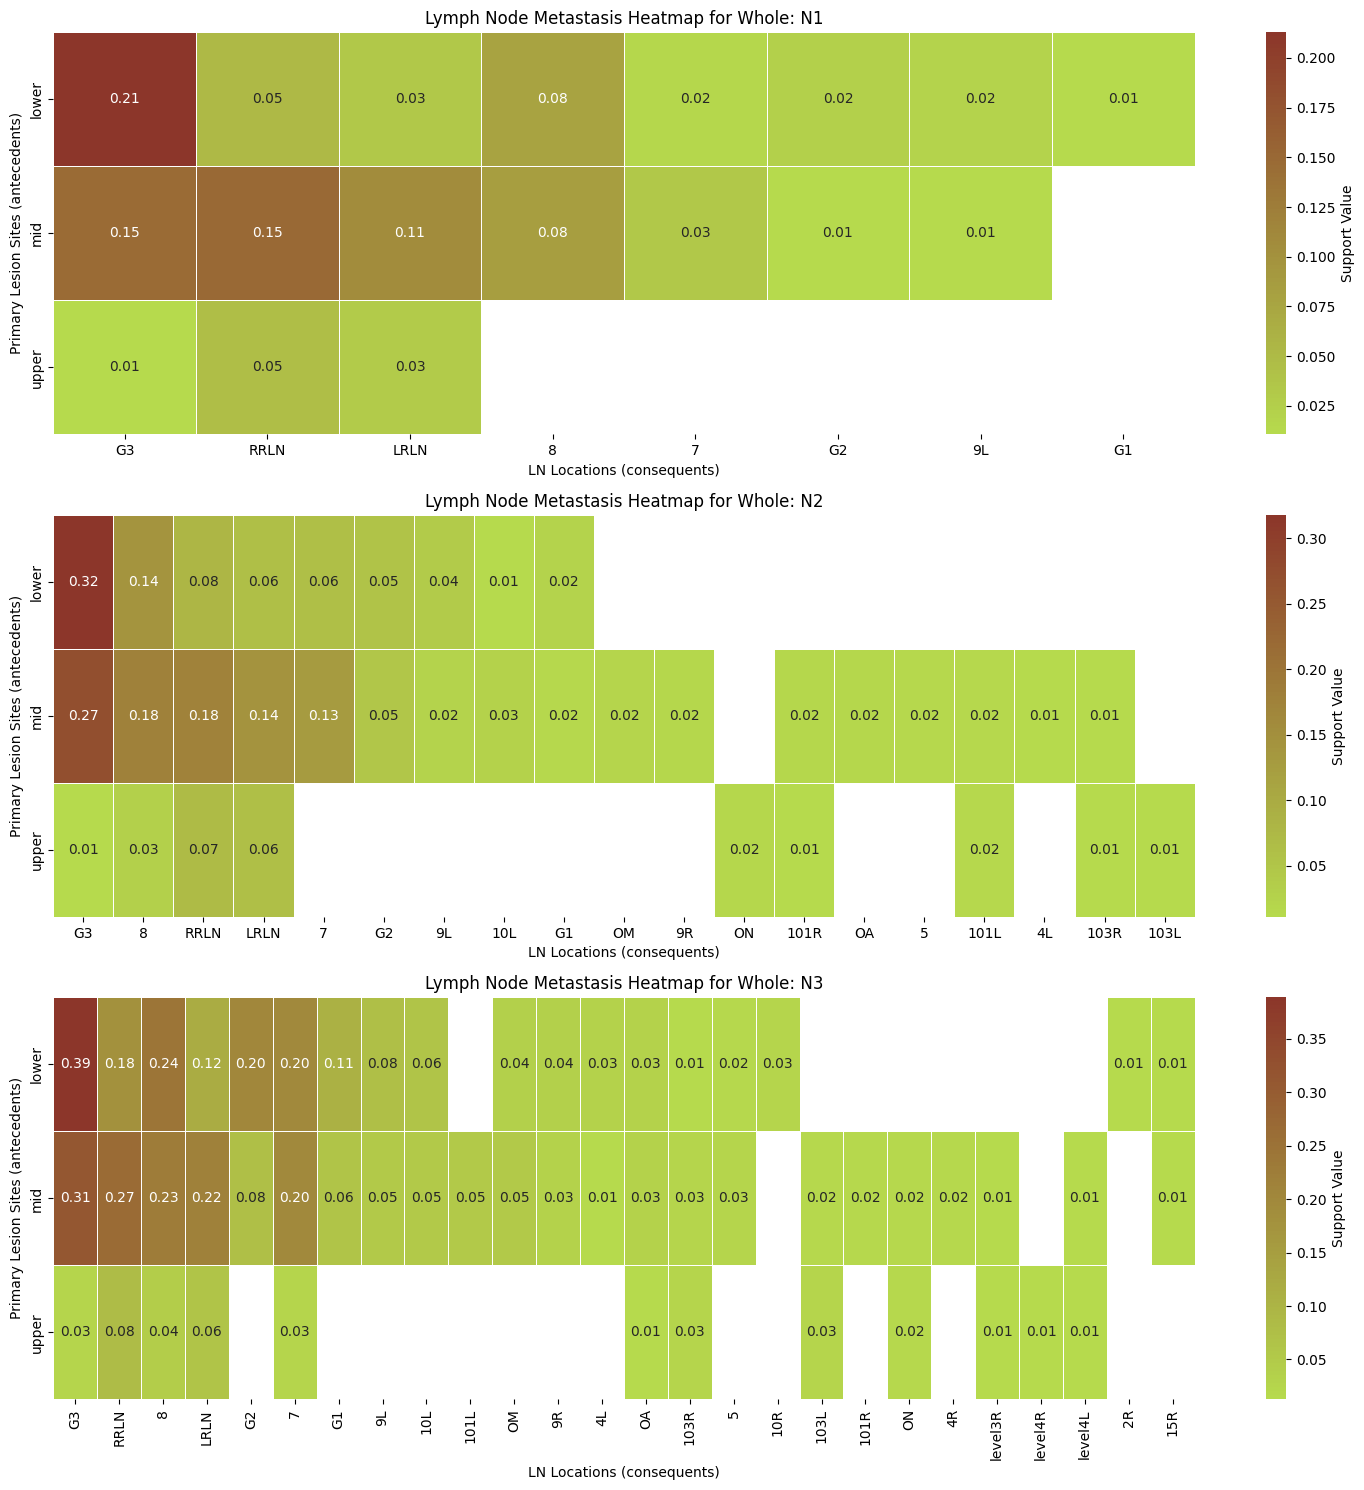

In [20]:
plot_combined_heatmap_support(associationRule_PS_N1_Whole, associationRule_PS_N2_Whole, associationRule_PS_N3_Whole, 'Whole')

C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:62: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'confidence')
C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:62: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'confidence')
C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:62: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'confidence')


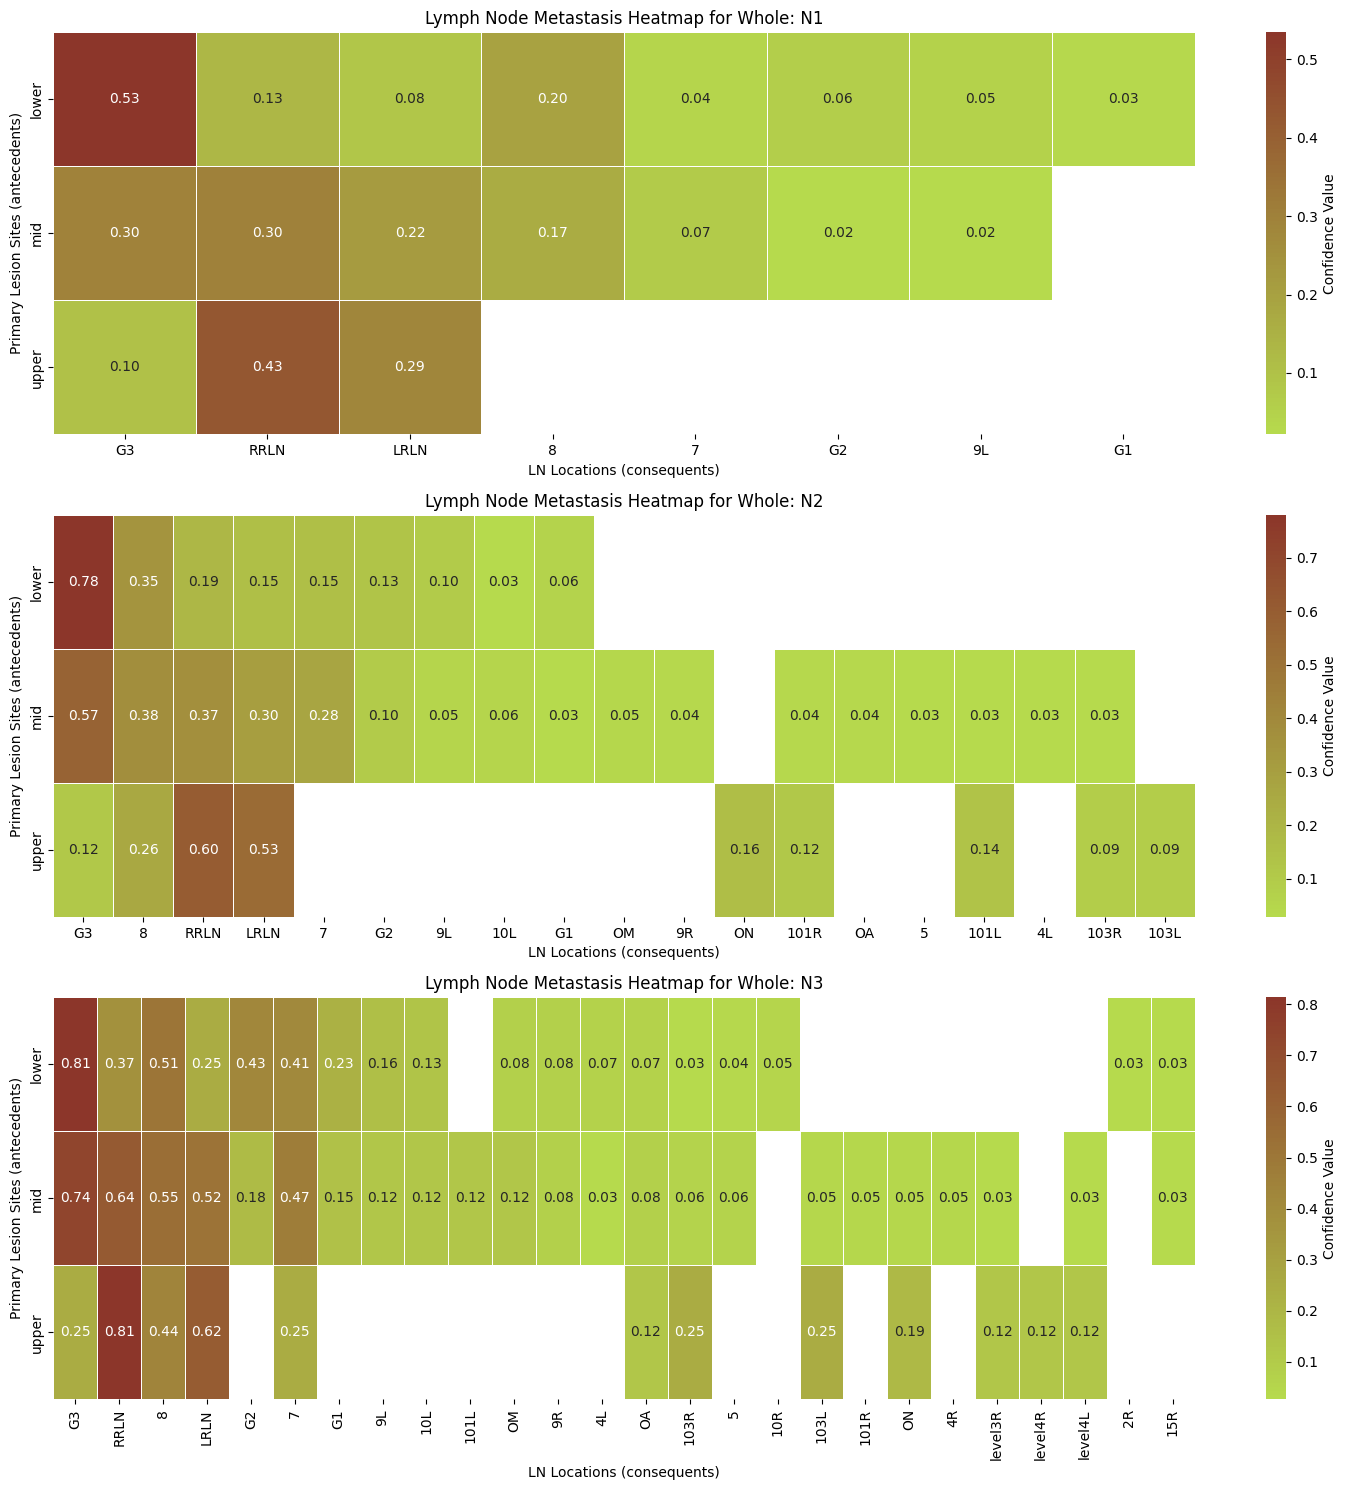

In [21]:
plot_combined_heatmap_confidence(associationRule_PS_N1_Whole, associationRule_PS_N2_Whole, associationRule_PS_N3_Whole, 'Whole')

C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:25: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'support')
C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:25: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'support')
C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:25: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'support')


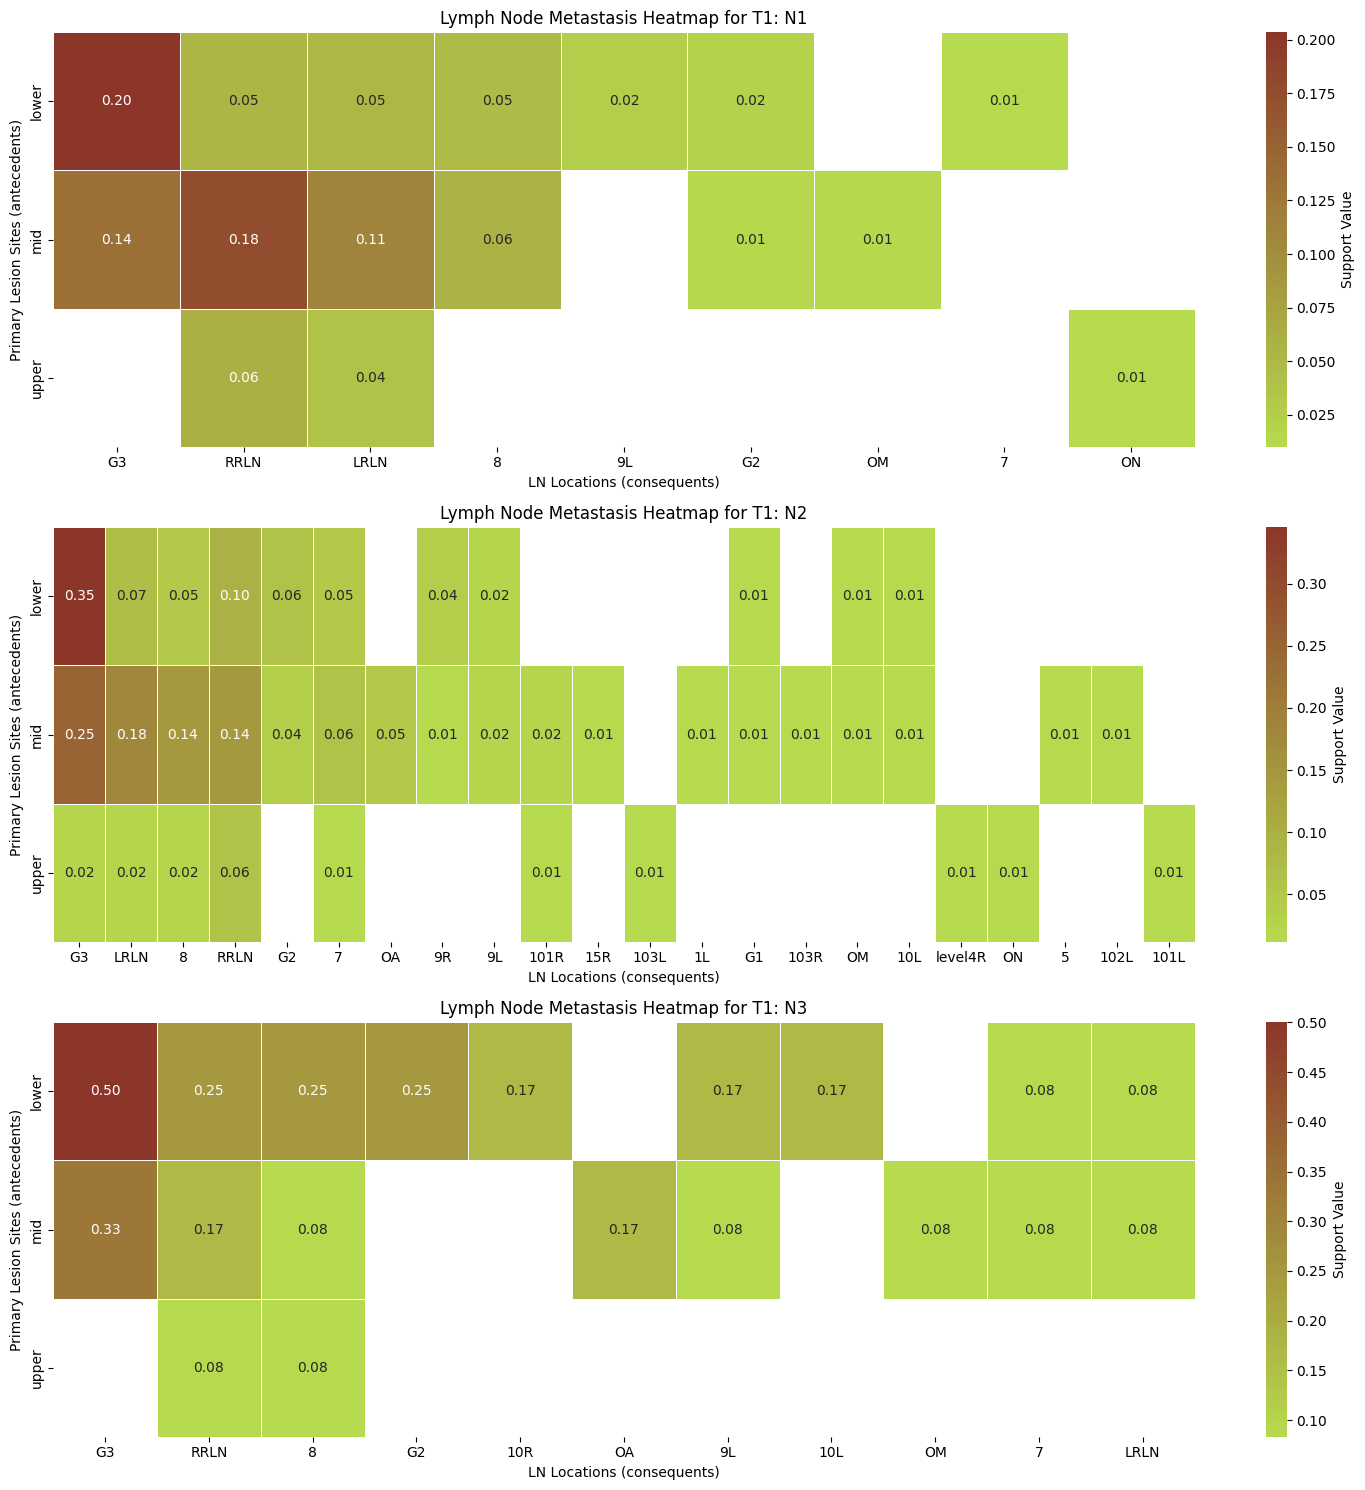

In [22]:
plot_combined_heatmap_support(associationRule_PS_N1_T1, associationRule_PS_N2_T1, associationRule_PS_N3_T1, 'T1')

C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:62: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'confidence')
C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:62: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'confidence')
C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:62: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'confidence')


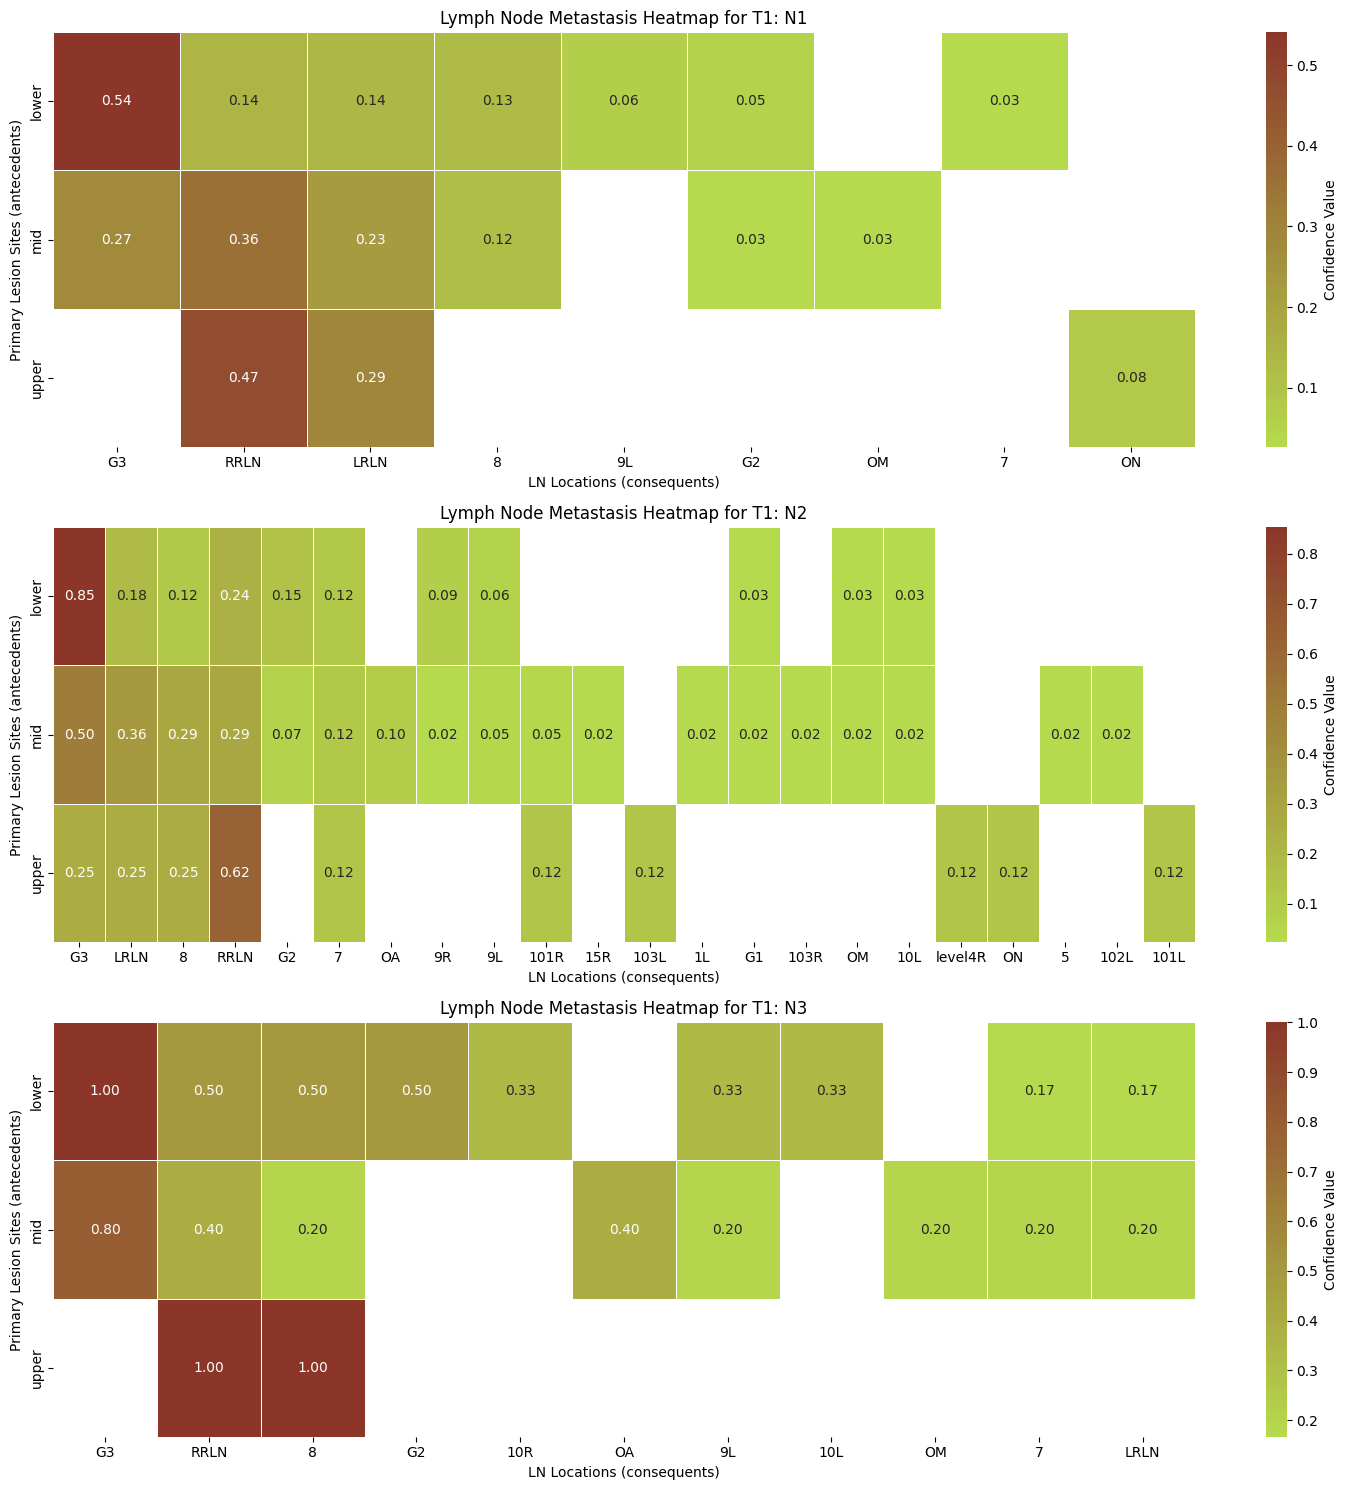

In [23]:
plot_combined_heatmap_confidence(associationRule_PS_N1_T1, associationRule_PS_N2_T1, associationRule_PS_N3_T1, 'T1')

C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:25: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'support')
C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:25: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'support')
C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:25: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'support')


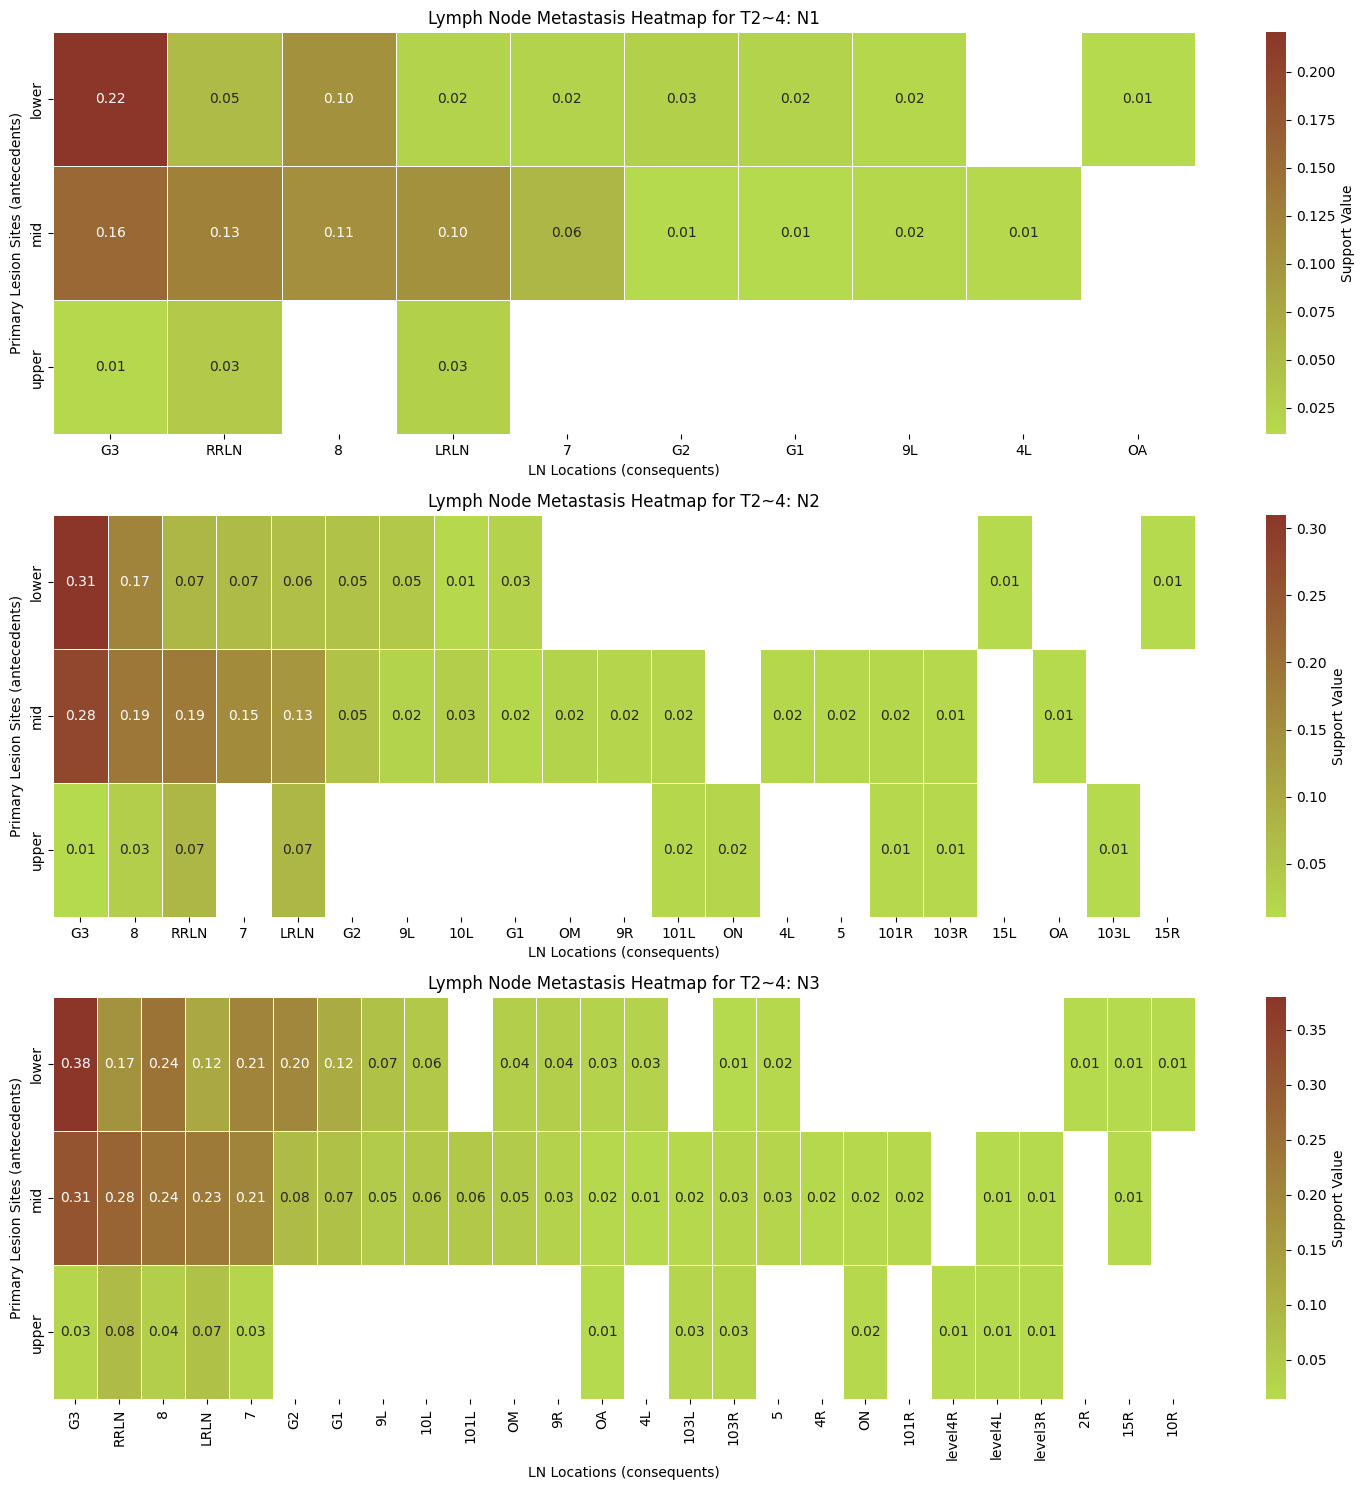

In [24]:
plot_combined_heatmap_support(associationRule_PS_N1_T24, associationRule_PS_N2_T24, associationRule_PS_N3_T24, 'T2~4')

C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:62: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'confidence')
C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:62: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'confidence')
C:\Users\user\AppData\Local\Temp\ipykernel_22412\1051074662.py:62: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = df.pivot('antecedents', 'consequents', 'confidence')


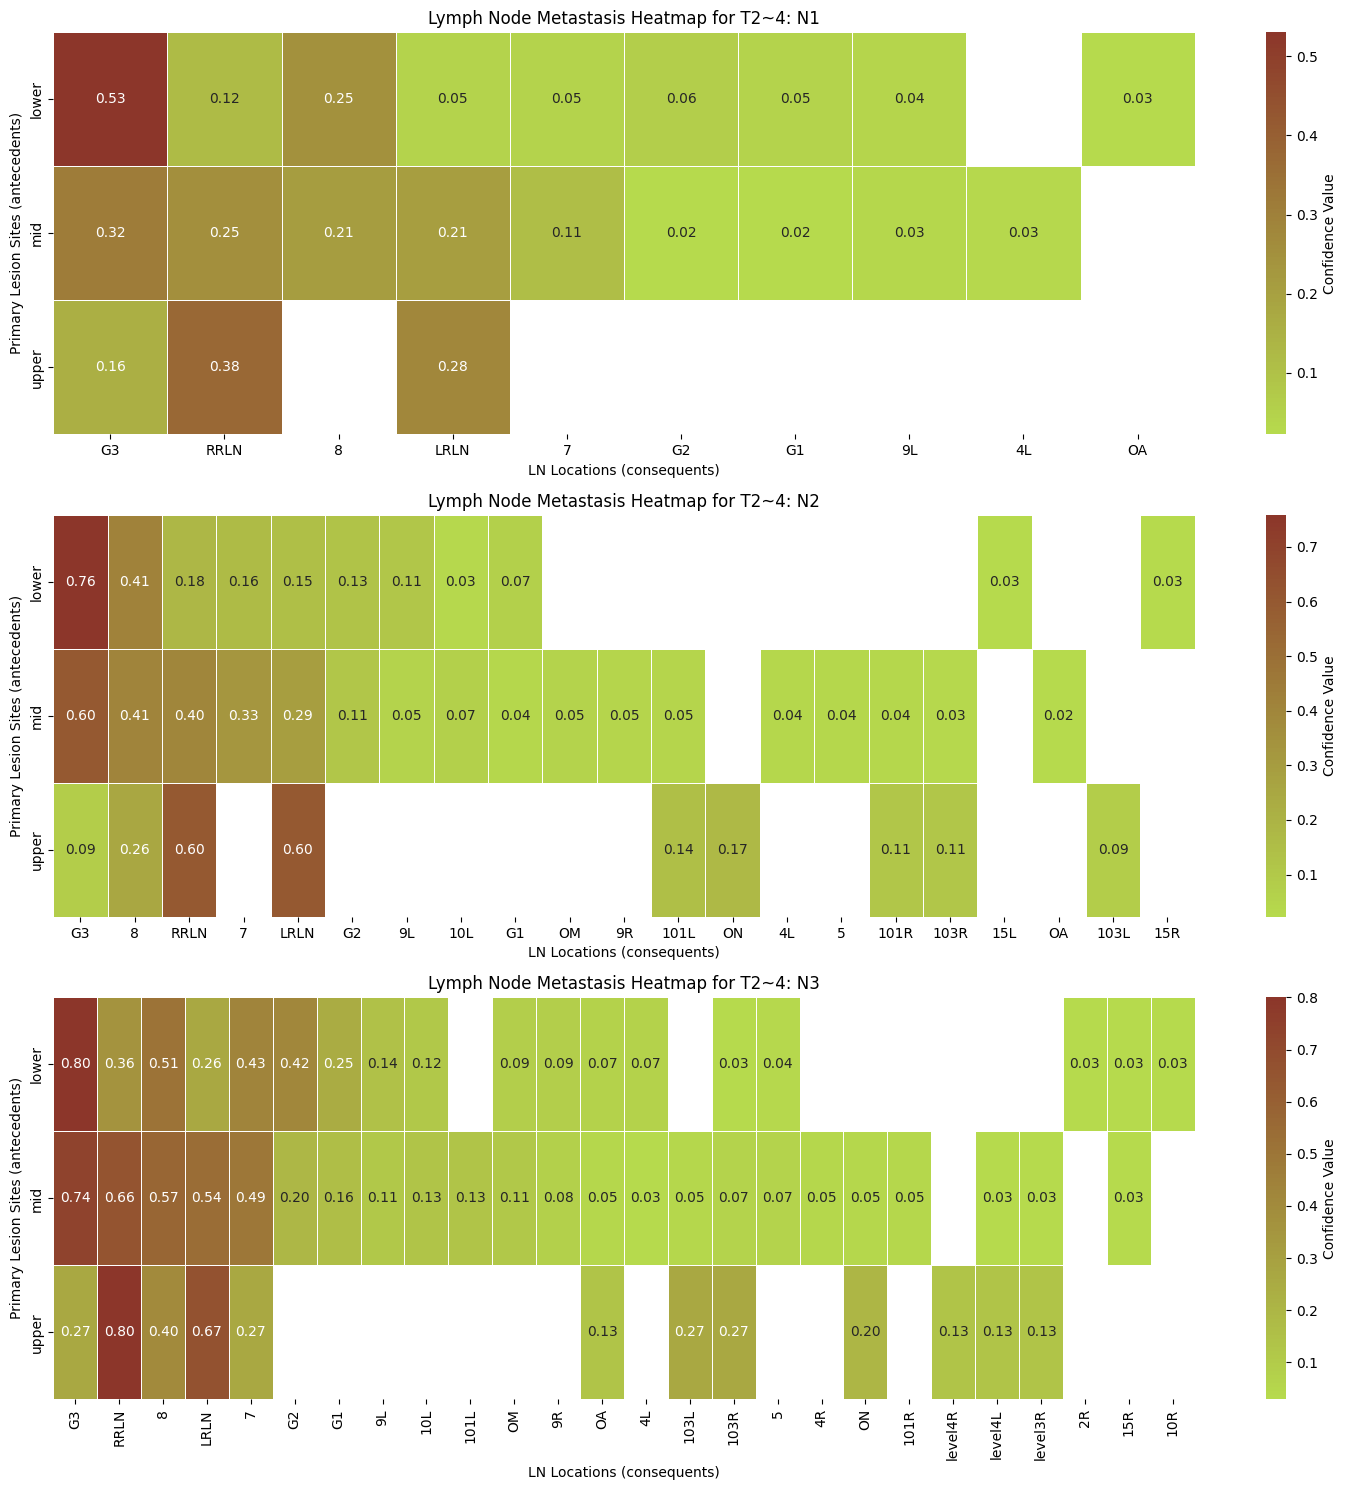

In [25]:
plot_combined_heatmap_confidence(associationRule_PS_N1_T24, associationRule_PS_N2_T24, associationRule_PS_N3_T24, 'T2~4')

#### 2D Heatmap for PS LN 

In [43]:
def transform_for_heatmap(descriptor):
    numbers = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
    
    # Initialize an empty DataFrame to store the transformed data
    transformed_df = pd.DataFrame(columns=['Number', 'LymphNode', 'Confidence', 'primarySite'])
    
    for num in numbers:
        # Construct the DataFrame name
        df_name = f"associationRule_PS_{num}_{descriptor}"
        
        # Check if DataFrame with the name exists
        if df_name in globals():
            df = globals()[df_name]
            
            # Filter rows based on specific lymph node locations
            specific_locations = ['RRLN', 'LRLN', '7', '8', 'G3', 'G2']
            filtered_df = df[df['consequents'].isin(specific_locations)]
            
            # Create a new DataFrame with the necessary columns
            new_df = filtered_df[['antecedents', 'consequents', 'confidence']].copy()
            new_df['Number'] = num
            new_df.columns = ['primarySite', 'LymphNode', 'Confidence', 'Number']
            
            # Append to the transformed DataFrame
            transformed_df = pd.concat([transformed_df, new_df], ignore_index=True)
            
    return transformed_df

def plot_transformed_heatmap(df, name):
    """
    Generate a heatmap using the transformed DataFrame.
    """
    # Handle duplicates for 'T1' and 'T24' by keeping the highest confidence value
    if name in ['T1', 'T24']:
        df.sort_values('Confidence', ascending=False, inplace=True)
        df.drop_duplicates(subset=['LymphNode', 'Number'], keep='first', inplace=True)
    
    # Custom color map
    color_list = ['#B6DA4D', '#8C362A']
    cmap = LinearSegmentedColormap.from_list("custom_cmap", color_list, N=100)
    
    # Define all lymph node locations and metastasis numbers
    all_locations = ['RRLN', 'LRLN', '7', '8', 'G3', 'G2']
    all_numbers = list(map(str, range(1, 11)))  
    
    # Create an empty DataFrame with all possible combinations
    heatmap_data = pd.DataFrame(index=all_locations, columns=all_numbers)
    
    # Update it with actual data
    for idx, row in df.iterrows():
        heatmap_data.at[row['LymphNode'], str(row['Number'])] = row['Confidence']
    
    # Replace empty strings with np.nan for heatmap plotting
    heatmap_data.replace('', np.nan, inplace=True)
    
    # Convert data to float
    heatmap_data = heatmap_data.astype(float)
    
    # Sort the columns numerically
    heatmap_data.columns = heatmap_data.columns.astype(int)
    heatmap_data.sort_index(axis=1, inplace=True)
    heatmap_data.columns = heatmap_data.columns.astype(str)
    
    # Remove any NaN only columns or rows to avoid double labels
    heatmap_data.dropna(axis=0, how='all', inplace=True)
    heatmap_data.dropna(axis=1, how='all', inplace=True)
    
    # Create a figure to hold the plot
    plt.figure(figsize=(15, 8))
    
    # Create the heatmap
    sns.heatmap(heatmap_data, cmap=cmap, annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': 'Confidence Value'})
    plt.title(f'Lymph Node Metastasis Heatmap for {name}')
    plt.xlabel('Metastasis Number')
    plt.ylabel('Specific Lymph Node Locations')
    plt.tight_layout()
    
    plt.show()

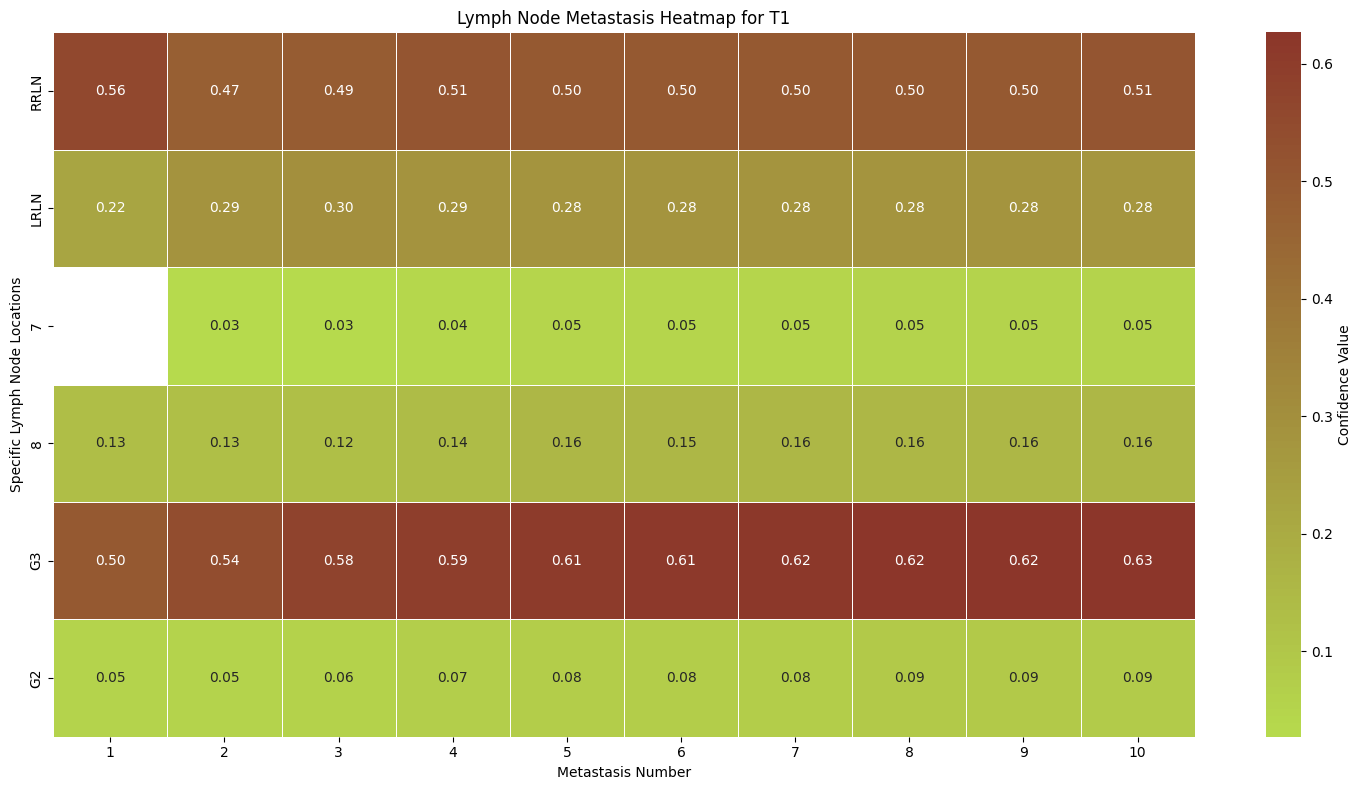

In [27]:
transformed_df_T1 = transform_for_heatmap('T1')
plot_transformed_heatmap(transformed_df_T1, 'T1')

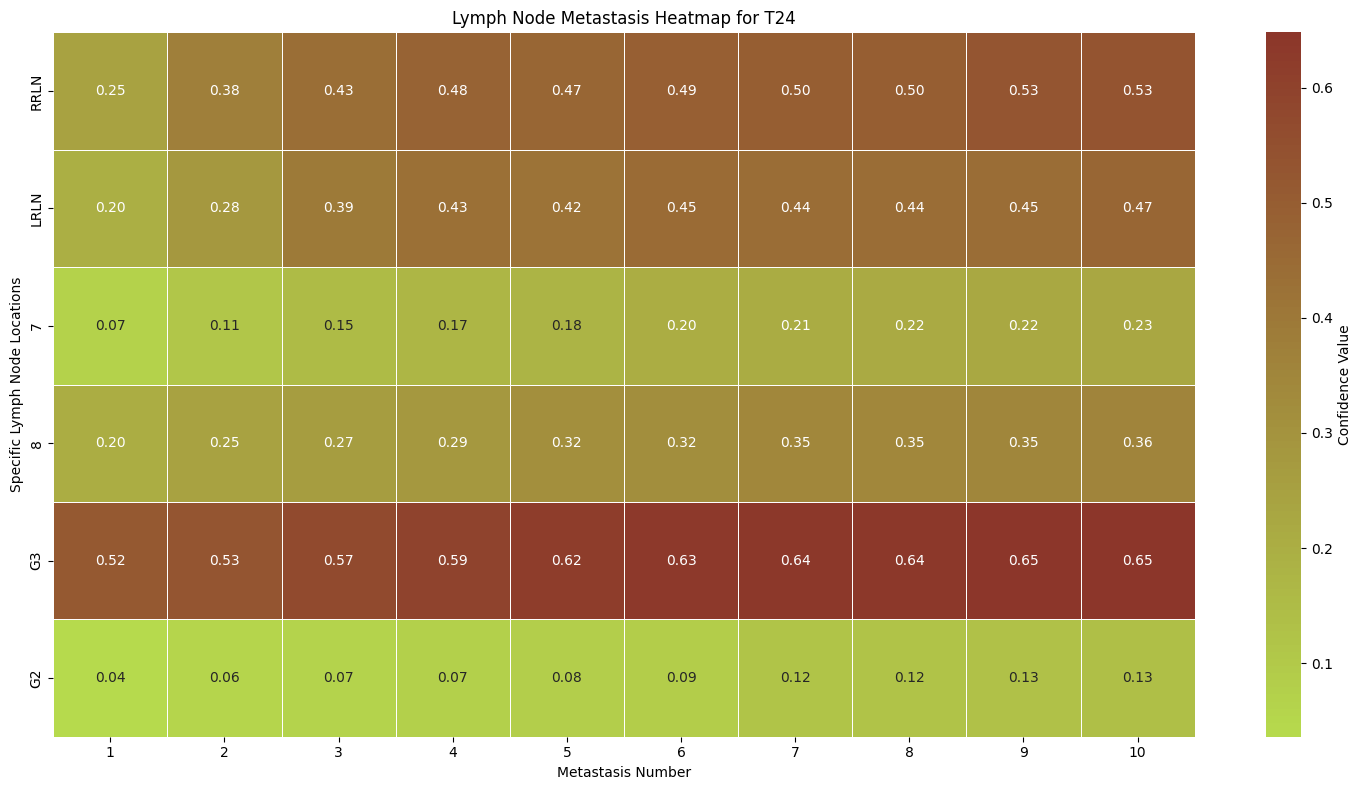

In [28]:
transformed_df_T24 = transform_for_heatmap('T24')
plot_transformed_heatmap(transformed_df_T24, 'T24')


In [29]:
def plot_multiple_transformed_heatmaps(dfs, names):
    """
    Generate multiple heatmaps using a list of transformed DataFrames.
    
    Parameters:
    dfs (list): List of transformed DataFrames suitable for heatmap plotting
    names (list): List of names for the heatmap titles
    """
    
    # Handle duplicates for 'T1' and 'T24' by keeping the highest confidence value
    if names in ['T1', 'T24']:
        df.sort_values('Confidence', ascending=False, inplace=True)
        df.drop_duplicates(subset=['LymphNode', 'Number'], keep='first', inplace=True)
    
    # Custom color map
    color_list = ['#B6DA4D', '#8C362A']
    cmap = LinearSegmentedColormap.from_list("custom_cmap", color_list, N=100)
    
    # Create a figure to hold the subplots
    plt.figure(figsize=(15, 8 * len(dfs)))
    
    for i, (df, name) in enumerate(zip(dfs, names)):
        plt.subplot(len(dfs), 1, i + 1)
        
        # Define all lymph node locations and metastasis numbers
        all_locations = ['RRLN', 'LRLN', '7', '8', 'G3', 'G2']
        all_numbers = list(map(str, range(1, 11)))  # Convert to strings for consistent dtype
        
        # Create an empty DataFrame with all possible combinations
        heatmap_data = pd.DataFrame(index=all_locations, columns=all_numbers)
        
        # Update it with actual data
        for idx, row in df.iterrows():
            heatmap_data.at[row['LymphNode'], str(row['Number'])] = row['Confidence']  # Convert Number to string
        
        # Replace empty strings with np.nan for heatmap plotting
        heatmap_data.replace('', np.nan, inplace=True)
        
        # Convert data to float
        heatmap_data = heatmap_data.astype(float)
        
        # Sort the columns numerically
        heatmap_data.columns = heatmap_data.columns.astype(int)
        heatmap_data.sort_index(axis=1, inplace=True)
        heatmap_data.columns = heatmap_data.columns.astype(str)
        
        # Create the heatmap
        sns.heatmap(heatmap_data, cmap=cmap, annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': 'Confidence Value'})
        plt.title(f'Lymph Node Metastasis Heatmap for {name}')
        plt.xlabel('Metastasis Number')
        plt.ylabel('Specific Lymph Node Locations')
    
    plt.tight_layout()
    # Save the figure
    save_path = f"../Results/2D_Heatmap_{names}.png"
    plt.savefig(save_path)
    
    plt.show()

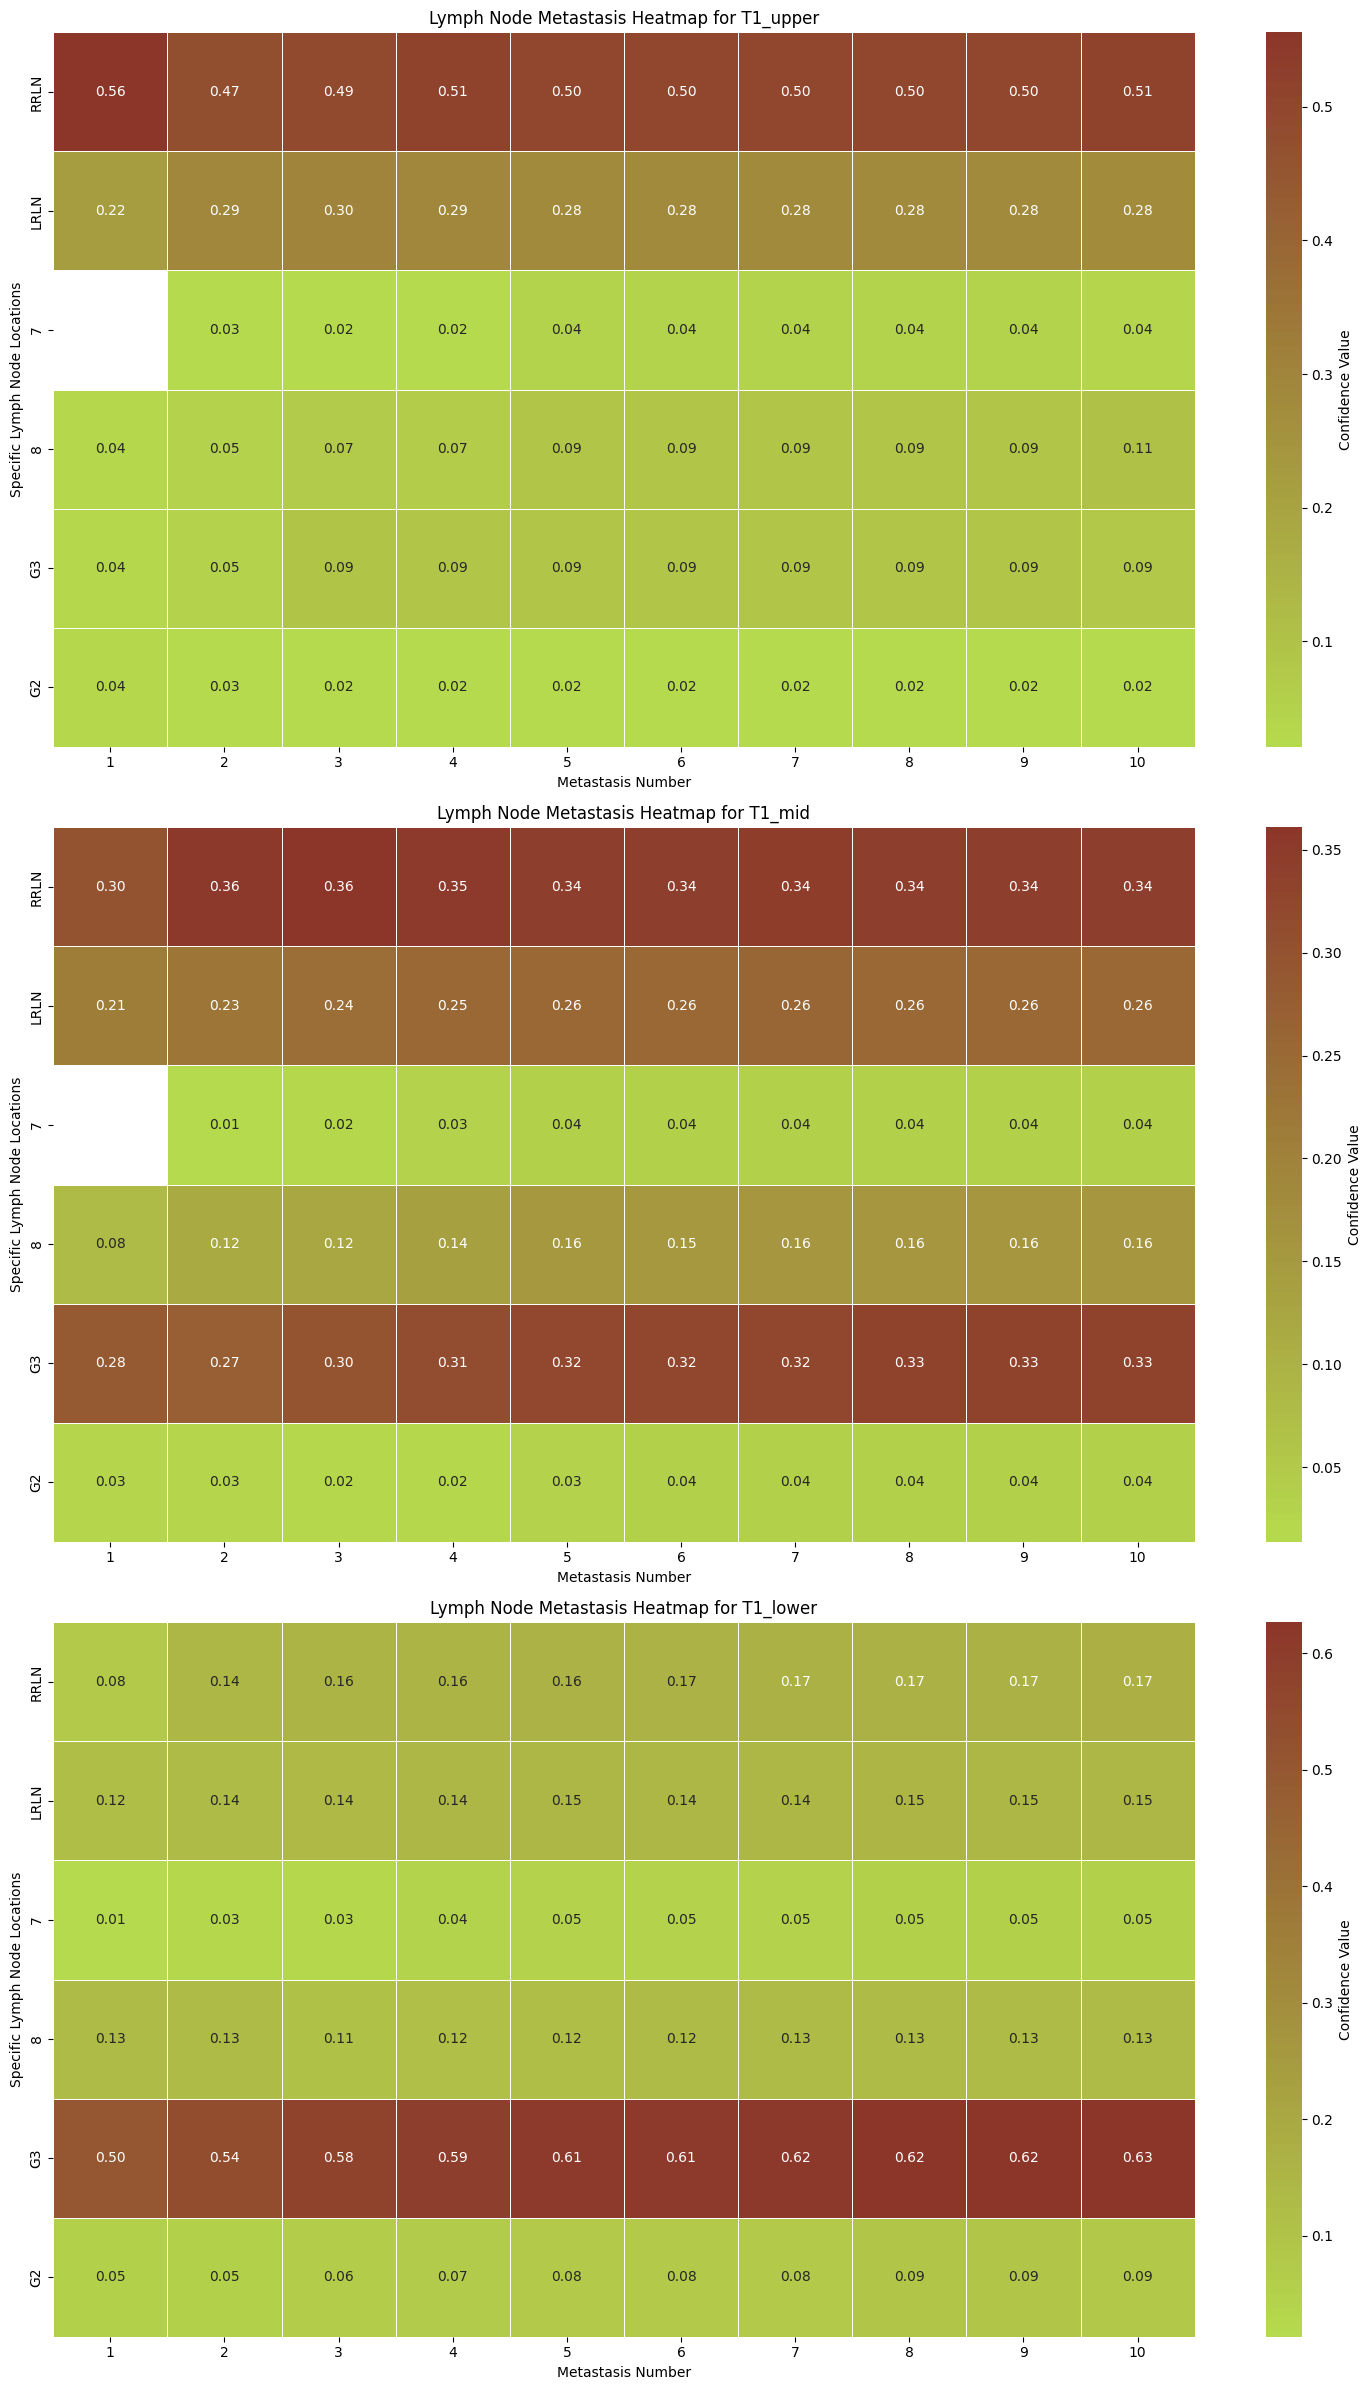

In [31]:
# Create the transformed DataFrames for T1_upper, T1_mid, and T1_lower
transformed_df_T1_upper = transform_for_heatmap('T1_upper')
transformed_df_T1_mid = transform_for_heatmap('T1_mid')
transformed_df_T1_lower = transform_for_heatmap('T1_lower')

# Create the multiple heatmaps
plot_multiple_transformed_heatmaps([transformed_df_T1_upper, transformed_df_T1_mid, transformed_df_T1_lower], ['T1_upper', 'T1_mid', 'T1_lower'])

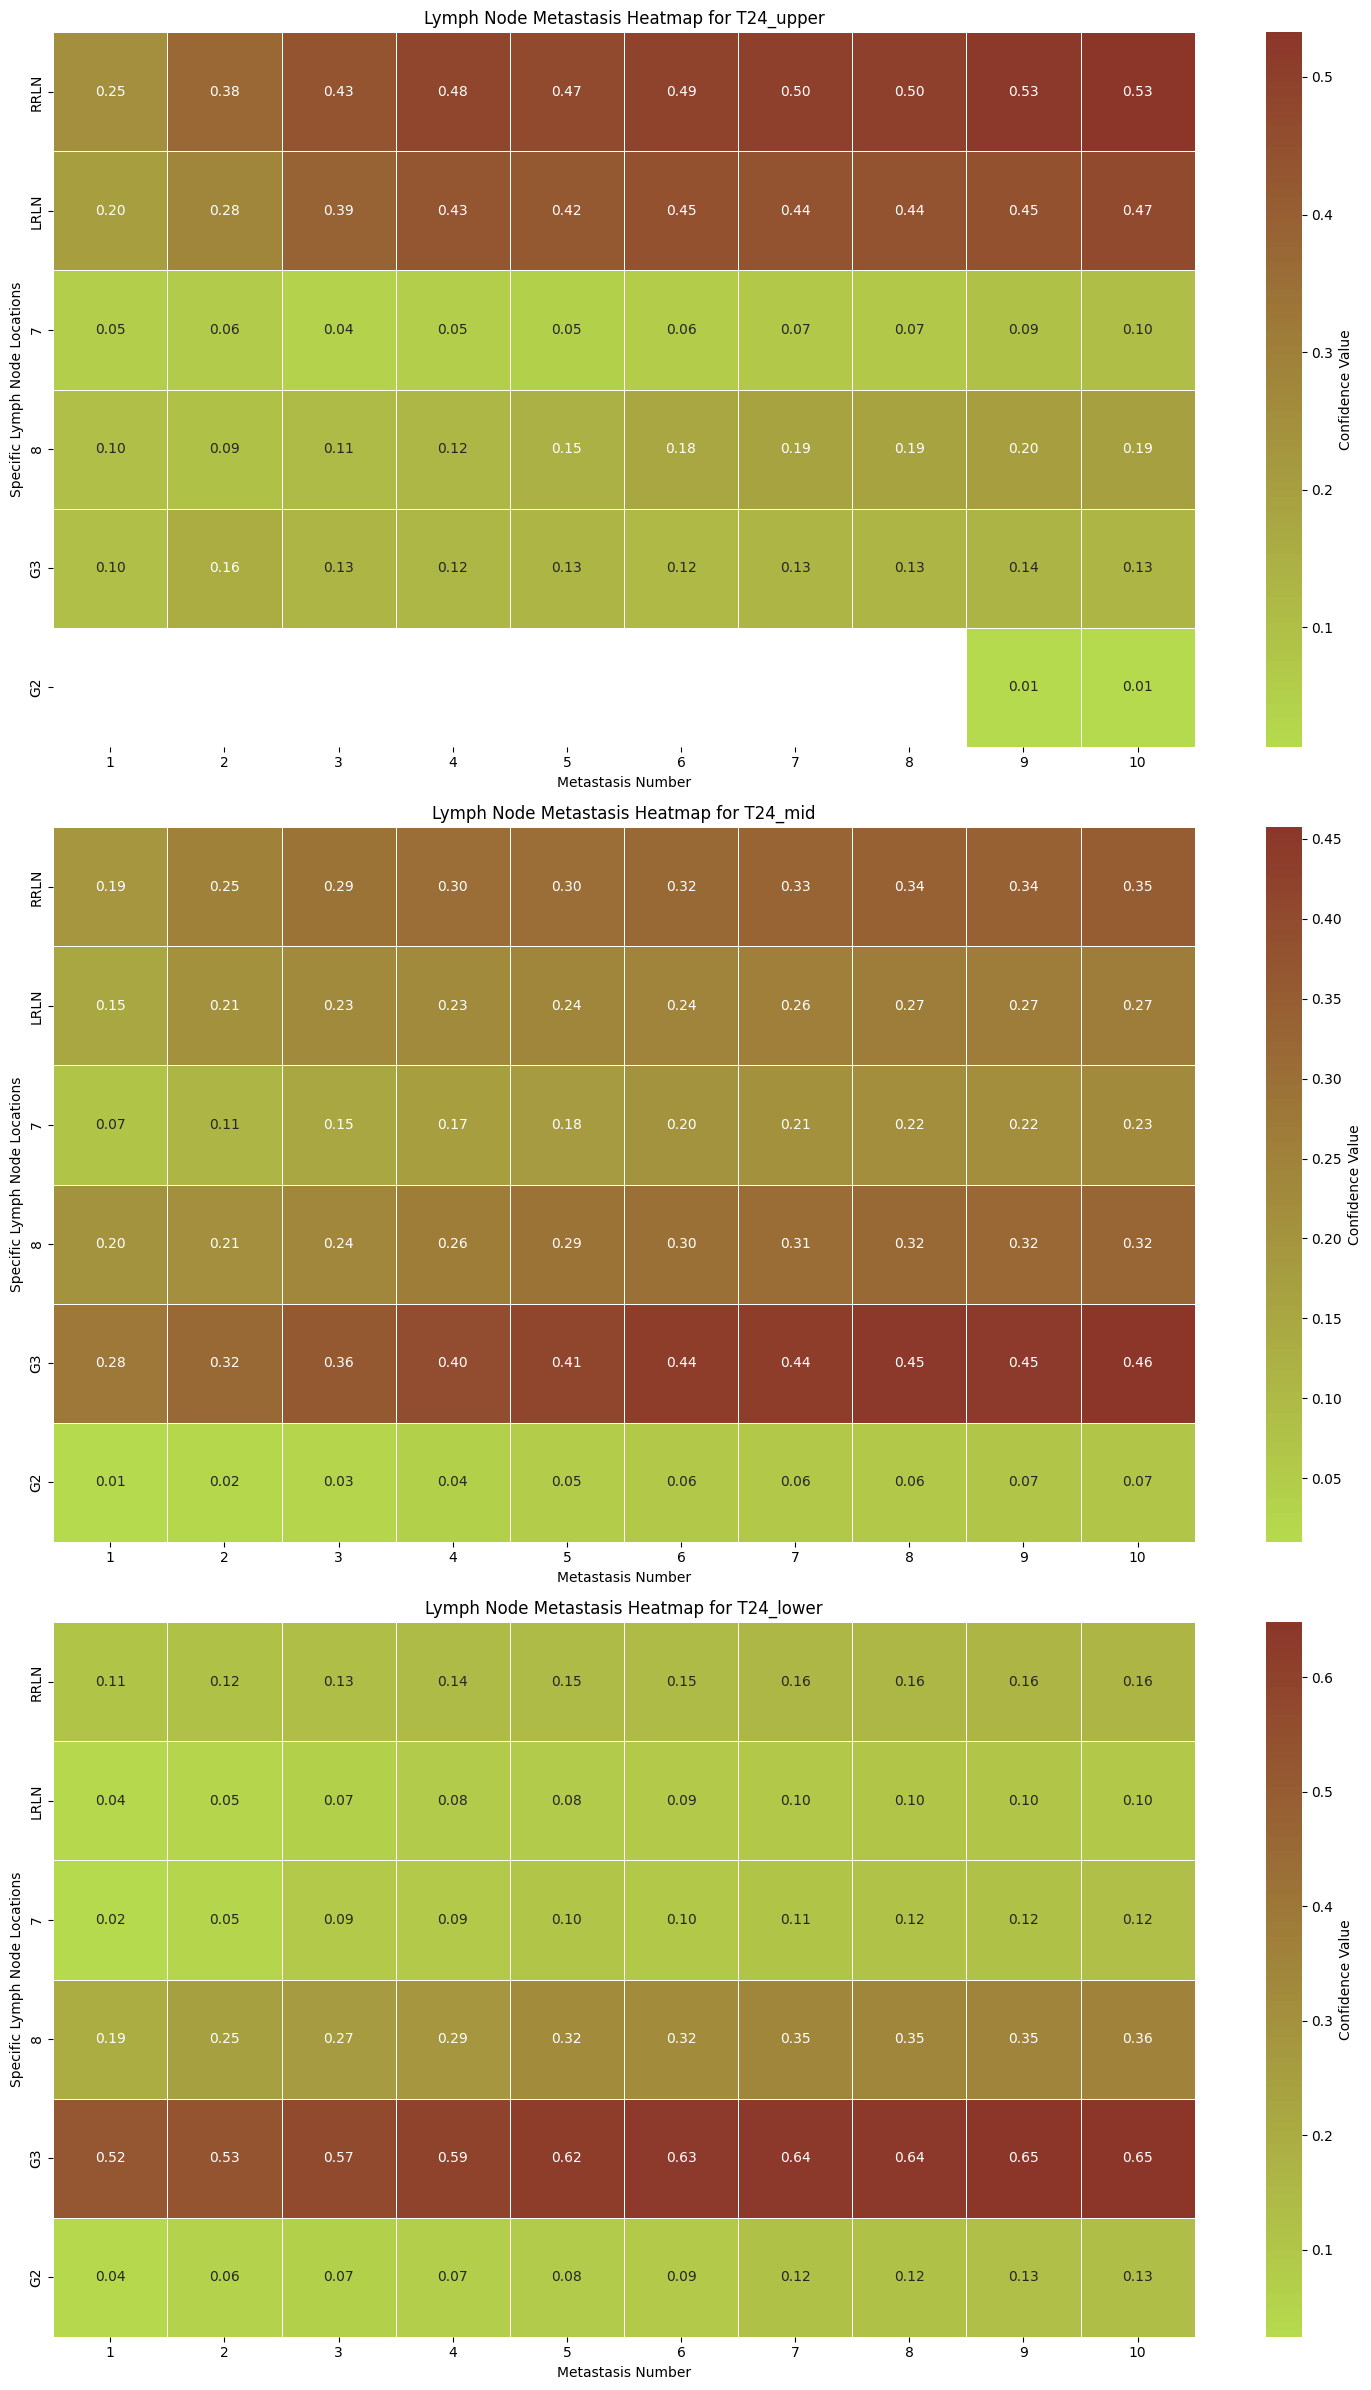

In [32]:
# Create the transformed DataFrames for T24_upper, T24_mid, and T24_lower
transformed_df_T24_upper = transform_for_heatmap('T24_upper')
transformed_df_T24_mid = transform_for_heatmap('T24_mid')
transformed_df_T24_lower = transform_for_heatmap('T24_lower')

# Create the multiple heatmaps
plot_multiple_transformed_heatmaps([transformed_df_T24_upper, transformed_df_T24_mid, transformed_df_T24_lower], ['T24_upper', 'T24_mid', 'T24_lower'])

#### 2D Heat map for Hub Nodes

In [57]:
def get_frequency_TN(df, count, category):        
    # Defining the columns related to positive lymph node counts (excluding sum of regions)
    pos_columns = [col for col in df.columns if col.startswith('pos_')]
    
    # Excluding the specified columns from the lymph node stations
    excluded_columns = ["pos_neckLN", "pos_mediaLN", "pos_abdoLN"]
    specific_pos_columns = [col for col in pos_columns if col not in excluded_columns]
    
    # Filtering the patients based on counts and N_category
    if count == None:
        metastasis_df = df[df['N_category'] == category]
    if category == None:
        metastasis_df = df[df['total_pos_LN'] <= count]
        
    # Creating a list to store the edges of the network for up to 2 metastasis
    edges = []

    # Iterating through the filtered patients and creating edges from primary site to lymph node stations
    for index, row in metastasis_df.iterrows():        
        # Extracting the node stations with positive counts and ensuring the comparison is made with numeric values
        nodes = [col[4:] for col in specific_pos_columns if pd.to_numeric(row[col], errors='coerce') > 0]

        # Creating edges by connecting all the nodes within a patient
        patient_edges = [(nodes[i], nodes[j]) for i in range(len(nodes)) for j in range(i+1, len(nodes))]
        edges.extend(patient_edges)

    # Converting the edges to a DataFrame
    edges_df = pd.DataFrame(edges, columns=['Node_1', 'Node_2'])

    # Counting the frequency of each edge, then sort values
    edges_frequency = edges_df.groupby(['Node_1', 'Node_2']).size().reset_index(name='Frequency').sort_values(by='Frequency', ascending=False)

    return edges_frequency

# Function to identify hub nodes based on both unweighted degree and normalized strength
def identify_node_degrees(edge_frequency):
    # Initialize an empty graph
    G = nx.Graph()
    
    # Populate the graph based on edges and their frequencies
    for index, row in edge_frequency.iterrows():
        G.add_edge(row['Node_1'], row['Node_2'], weight=row['Frequency'])
    
    # Calculate the unweighted degree of each node
    node_degrees = dict(G.degree())
    
    # Calculate the total frequency (sum of all edge weights)
    total_frequency = sum(weight for _, _, weight in G.edges(data='weight'))
    
    # Calculate the normalized strength of each node
    node_normalized_strengths = {node: round(sum(weight / total_frequency for _, _, weight in G.edges(node, data='weight')), 3) for node in G.nodes()}
 
    # Create a DataFrame to store the nodes, their degrees, and normalized strengths
    hub_nodes_df = pd.DataFrame({
        'Node': list(node_degrees.keys()),
        'Unweighted Degree': list(node_degrees.values()),
        'Weighted Degree': [node_normalized_strengths.get(node, 0) for node in node_degrees.keys()]
    })
    
    # Sort the DataFrame based on both Weighted Degree
    hub_nodes_df.sort_values(by=['Weighted Degree'], ascending=[False], inplace=True)
    
    return hub_nodes_df

In [54]:
def transform_for_heatmap_TN(descriptor):
    numbers = ['2', '3', '4', '5', '6', '7', '8', '9', '10']
    
    # Initialize an empty DataFrame to store the transformed data
    transformed_df = pd.DataFrame(columns=['Number', 'HubNodes', 'Support'])
    
    # Identify the top 5 hub nodes from edge frequencies
    ef_name = f"EF_TN_{numbers}_{descriptor}"  # Replace with the appropriate name
    if ef_name in globals():
        edge_frequency_df = globals()[ef_name]
        hub_nodes_df = identify_node_degrees(edge_frequency_df)
        top_hub_nodes = hub_nodes_df['Node'].head(5).tolist()
    
    for num in numbers:
        # Construct the DataFrame name for association rules
        df_name = f"associationRule_TN_{num}_{descriptor}"
        
        # Check if DataFrame with the name exists
        if df_name in globals():
            df = globals()[df_name]
            
            # Filter rows based on specific hub nodes
            filtered_df = df[df['antecedents'].isin(top_hub_nodes)]
            
            # Create a new DataFrame with the necessary columns
            new_df = filtered_df[['antecedents', 'consequents', 'support']].copy()
            new_df['Number'] = num
            new_df.columns = ['HubNodes', 'LymphNode', 'Support', 'Number']
            
            # Append to the transformed DataFrame
            transformed_df = pd.concat([transformed_df, new_df], ignore_index=True)
            
    return transformed_df

def plot_transformed_heatmap_TN(df, name, top_hub_nodes):
    # Custom color map
    cmap = sns.color_palette("coolwarm", as_cmap=True)
    
    # Create an empty DataFrame with all possible combinations
    heatmap_data = pd.DataFrame(index=top_hub_nodes, columns=list(map(str, range(1, 11))))
    
    # Update it with actual data
    for idx, row in df.iterrows():
        heatmap_data.at[row['HubNodes'], str(row['Number'])] = row['Support']
    
    # Replace empty strings with np.nan for heatmap plotting
    heatmap_data.replace('', np.nan, inplace=True)
    
    # Convert data to float
    heatmap_data = heatmap_data.astype(float)
    
    # Create a figure to hold the plot
    plt.figure(figsize=(15, 8))
    
    # Create the heatmap
    sns.heatmap(heatmap_data, cmap=cmap, annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': 'Support Value', 'vmin': 0, 'vmax': 0.8})
    plt.title(f'Lymph Node Metastasis Heatmap for {name}')
    plt.xlabel('Metastasis Number')
    plt.ylabel('Hub Nodes')
    plt.tight_layout()
    
    plt.show()

In [64]:
#Get edges frequencies based on Numbers
for descriptor in dataset_descriptors:
    for num in numbers:
        label = 'all' if num == 44 else str(num)
        # Create the global variable name
        var_name = f"EF_TN_{label}_{descriptor}"
        # Create the dataframe variable name
        df_name = f"{descriptor}_df"
        # Assign the result to the global variable
        globals()[var_name] = get_frequency_TN(globals()[df_name], num, None)
        
#Get edges frequency based on N categories
for descriptor in dataset_descriptors:
    for category in N_categories:
        label = f'N{category}'
        # Create the global variable name
        var_name = f"EF_TN_{label}_{descriptor}"
        # Create the dataframe variable name
        df_name = f"{descriptor}_df"
        # Assign the result to the global variable
        globals()[var_name] = get_frequency_TN(globals()[df_name], None, category)

In [65]:
identify_node_degrees(EF_TN_2_T1_upper)

TypeError: identify_top_hub_nodes() missing 1 required positional argument: 'descriptor'

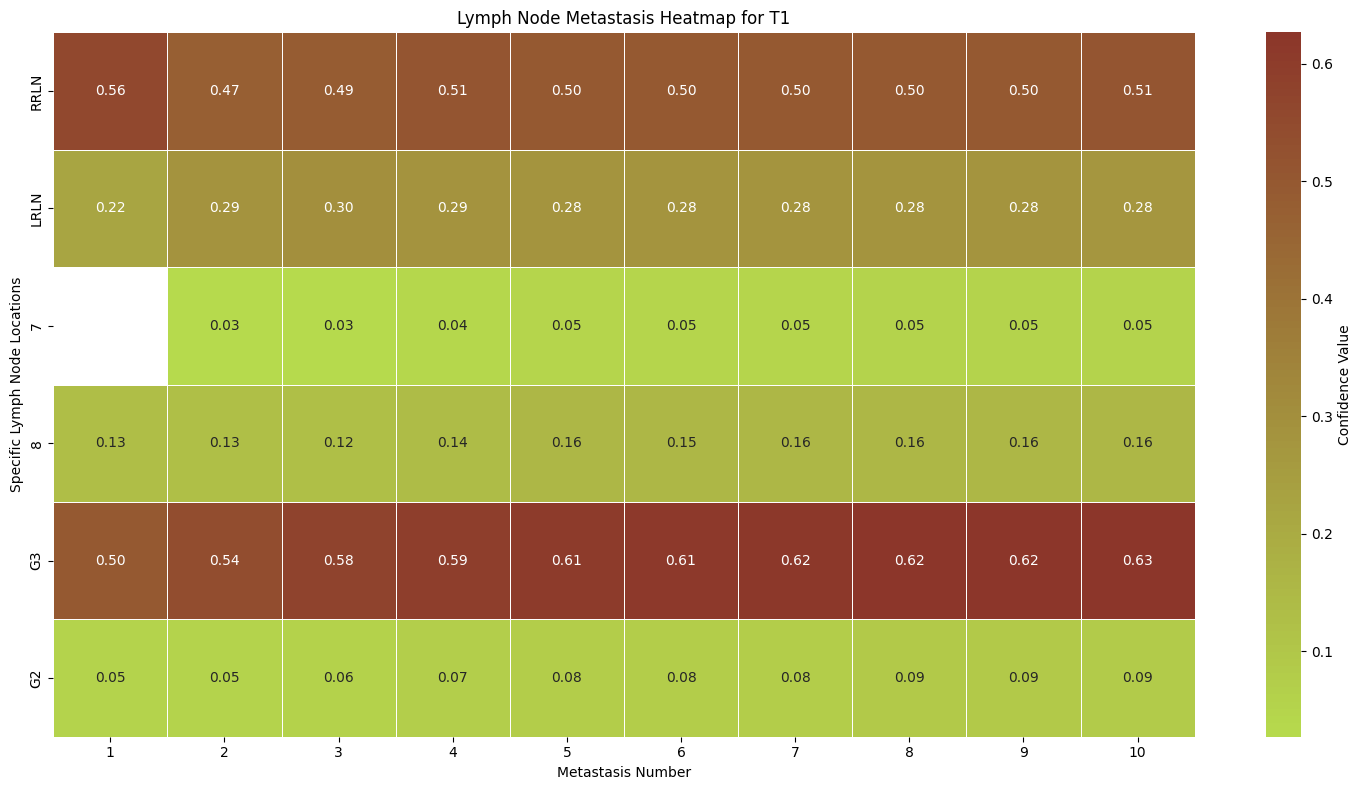

In [45]:
transformed_df_T1 = transform_for_heatmap('T1')
plot_transformed_heatmap(transformed_df_T1, 'T1')

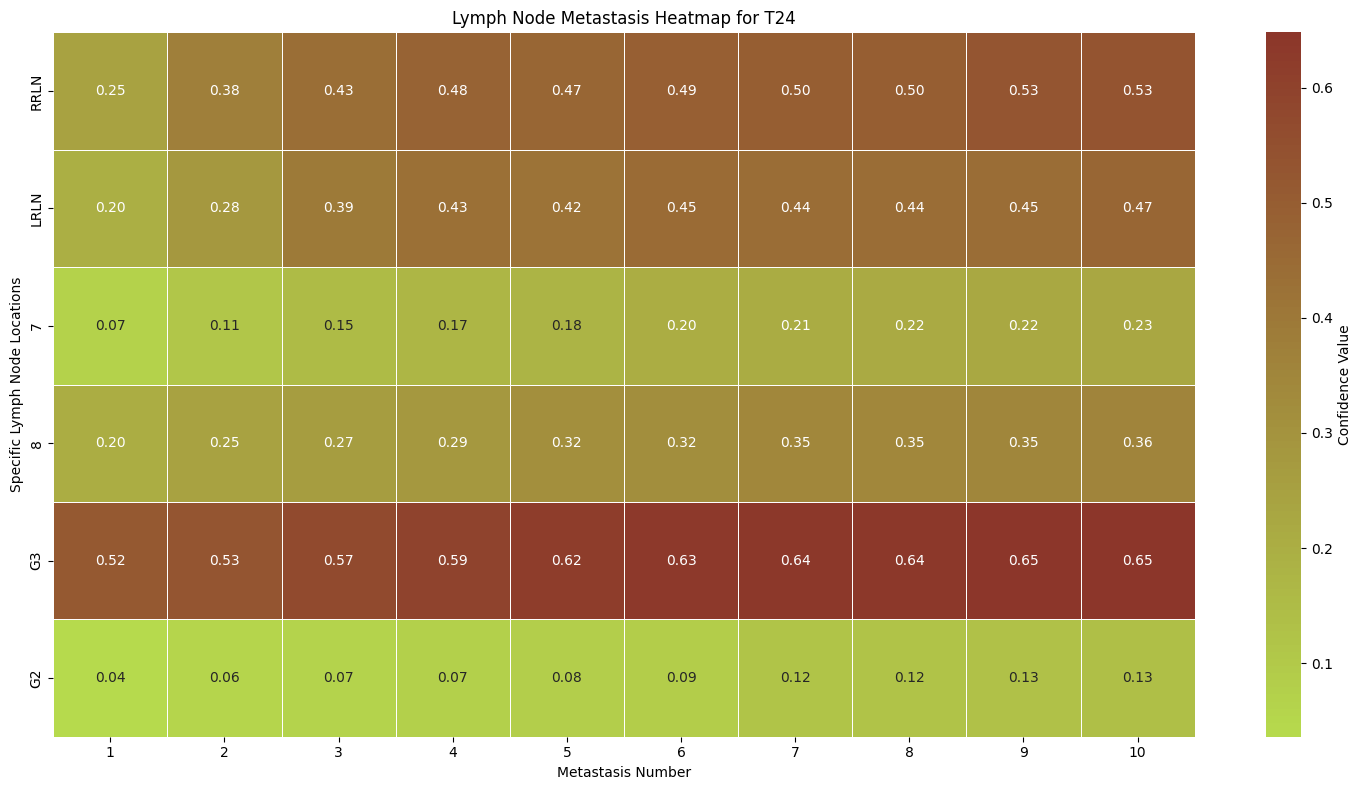

In [46]:
transformed_df_T24 = transform_for_heatmap('T24')
plot_transformed_heatmap(transformed_df_T24, 'T24')

In [47]:
def plot_multiple_transformed_heatmaps(dfs, names):
    """
    Generate multiple heatmaps using a list of transformed DataFrames.
    
    Parameters:
    dfs (list): List of transformed DataFrames suitable for heatmap plotting
    names (list): List of names for the heatmap titles
    """
    
    # Handle duplicates for 'T1' and 'T24' by keeping the highest confidence value
    if names in ['T1', 'T24']:
        df.sort_values('Confidence', ascending=False, inplace=True)
        df.drop_duplicates(subset=['LymphNode', 'Number'], keep='first', inplace=True)
    
    # Custom color map
    color_list = ['#B6DA4D', '#8C362A']
    cmap = LinearSegmentedColormap.from_list("custom_cmap", color_list, N=100)
    
    # Create a figure to hold the subplots
    plt.figure(figsize=(15, 8 * len(dfs)))
    
    for i, (df, name) in enumerate(zip(dfs, names)):
        plt.subplot(len(dfs), 1, i + 1)
        
        # Define all lymph node locations and metastasis numbers
        all_locations = ['RRLN', 'LRLN', '7', '8', 'G3', 'G2']
        all_numbers = list(map(str, range(1, 11)))  # Convert to strings for consistent dtype
        
        # Create an empty DataFrame with all possible combinations
        heatmap_data = pd.DataFrame(index=all_locations, columns=all_numbers)
        
        # Update it with actual data
        for idx, row in df.iterrows():
            heatmap_data.at[row['LymphNode'], str(row['Number'])] = row['Confidence']  # Convert Number to string
        
        # Replace empty strings with np.nan for heatmap plotting
        heatmap_data.replace('', np.nan, inplace=True)
        
        # Convert data to float
        heatmap_data = heatmap_data.astype(float)
        
        # Sort the columns numerically
        heatmap_data.columns = heatmap_data.columns.astype(int)
        heatmap_data.sort_index(axis=1, inplace=True)
        heatmap_data.columns = heatmap_data.columns.astype(str)
        
        # Create the heatmap
        sns.heatmap(heatmap_data, cmap=cmap, annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': 'Confidence Value'})
        plt.title(f'Lymph Node Metastasis Heatmap for {name}')
        plt.xlabel('Metastasis Number')
        plt.ylabel('Specific Lymph Node Locations')
    
    plt.tight_layout()
    # Save the figure
    save_path = f"../Results/2D_Heatmap_{names}.png"
    plt.savefig(save_path)
    
    plt.show()

In [ ]:
# Create the transformed DataFrames for T1_upper, T1_mid, and T1_lower
transformed_df_T1_upper = transform_for_heatmap('T1_upper')
transformed_df_T1_mid = transform_for_heatmap('T1_mid')
transformed_df_T1_lower = transform_for_heatmap('T1_lower')

# Create the multiple heatmaps
plot_multiple_transformed_heatmaps([transformed_df_T1_upper, transformed_df_T1_mid, transformed_df_T1_lower], ['T1_upper', 'T1_mid', 'T1_lower'])

In [ ]:
# Create the transformed DataFrames for T24_upper, T24_mid, and T24_lower
transformed_df_T24_upper = transform_for_heatmap('T24_upper')
transformed_df_T24_mid = transform_for_heatmap('T24_mid')
transformed_df_T24_lower = transform_for_heatmap('T24_lower')

# Create the multiple heatmaps
plot_multiple_transformed_heatmaps([transformed_df_T24_upper, transformed_df_T24_mid, transformed_df_T24_lower], ['T24_upper', 'T24_mid', 'T24_lower'])

### 3D Plot

In [40]:
def plot_3D_line(df, name):
    fig = plt.figure(figsize=(15, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Sort DataFrame for plotting
    df.sort_values(by=['LymphNode', 'Number'], inplace=True)
    
    # Extract unique lymph node locations
    unique_locations = df['LymphNode'].unique()
    
    # Map lymph node locations to numerical values for plotting
    location_mapping = {location: i for i, location in enumerate(unique_locations)}
    df['LymphNodeIndex'] = df['LymphNode'].map(location_mapping)
    
    for location, index in location_mapping.items():
        # Filter data for each unique lymph node location
        subset_df = df[df['LymphNode'] == location]
        
        ax.plot(subset_df['Number'], [index] * len(subset_df), subset_df['Confidence'], label=location)
        
    ax.set_xlabel('Metastasis Number')
    ax.set_ylabel('Specific Lymph Node Locations')
    ax.set_zlabel('Confidence Value')
    ax.set_title(f'3D Line Plot of Lymph Node Metastasis for {name}')
    ax.set_yticks(list(location_mapping.values()))
    ax.set_yticklabels(list(location_mapping.keys()))
    
    ax.legend()
    plt.tight_layout()
    plt.show()
    
def plot_3D_bar_chart(df):
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Define all lymph node locations and metastasis numbers
    all_locations = ['RRLN', 'LRLN', '7', '8', 'G3', 'G2']
    all_numbers = list(range(1, 11))
    
    colors = ['r', 'g', 'b', 'y', 'c', 'm']  # Different colors for each lymph node location
    
    for i, location in enumerate(all_locations):
        location_data = df[df['LymphNode'] == location]
        for number in all_numbers:
            number_data = location_data[location_data['Number'] == number]
            confidence = number_data['Confidence'].iloc[0] if not number_data.empty else 0
            ax.bar3d(i, number, 0, 0.4, 0.8, confidence, shade=True, color=colors[i])
    
    ax.set_xticks(range(len(all_locations)))
    ax.set_xticklabels(all_locations)
    ax.set_yticks(all_numbers)
    ax.set_xlabel('LymphNode Locations')
    ax.set_ylabel('Metastasis Number')
    ax.set_zlabel('Confidence')
    plt.title('3D Bar Chart of Lymph Node Metastasis')
    plt.show()


In [41]:
# Plot the 3D line plot for T1_upper using the function
# plot_3D_line(transformed_df_T1_upper, 'T1_upper')

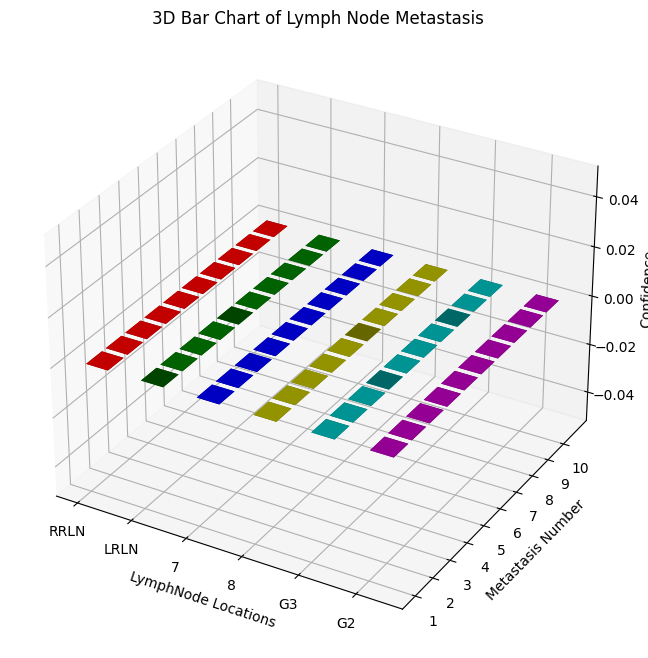

In [42]:
# Plot the 3D bar chart
plot_3D_bar_chart(transformed_df_T1_upper)